## Imports

In [2]:
from RegionMap import RegionMap
from Fleet import Monitoring_Fleet

import numpy as np
import os 
from datetime import datetime
import pandas as pd

## Set up

In [3]:
# Path to load the data

# Amélie
link = r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg"
df_link = pd.read_csv(r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

# # Orane
# link = r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg"
# df_link = pd.read_csv(r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

In [4]:
def run(link, df_link, File, id = 'pred_vdist', mode = 'random', load = True):

    
    # Set the parameters
    N_episodes = 300 
    ep_len     = 5

    buffer_size = 6000
    batch_size = 32

    # --- Create maps --- 

    # Map parameters
    x_size = 20
    y_size = 30

    if load:
        # Load maps - to adapt when we have all the maps  
        # Map.load_from_file(File)
        None
    
    else: 
        # initialize importance map
        Map = RegionMap(y_size, x_size, [], [], 1, df_link = df_link, link = link, listFileNumbers=File)
        Map.initialize_better_importance_map(id)

    # ----- Create a fleet -----
    
    drone_init_pos = [[5,7], [3,26], [10, 3], [10,26]]

    state_shape    = [ep_len, 13]    
    num_stacked = 2    
    alpha = 1e-3

    pretrained_folder = None 

    F = Monitoring_Fleet(Map, buffer_size, state_shape, pretrained_folder, True, num_stacked, alpha)
    F.add_drones(drone_init_pos) 


    #----- Create save folder paths -----
    
    np.set_printoptions(threshold=np.inf)
    
    current_folder = os.getcwd()
    save_folder = current_folder + "/Results"
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)    
        
    now = datetime.now()
    date_time = now.strftime("%m_%d_%Y_%H_%M_%S")    
    
    current_results = save_folder + "/" + date_time
    if not os.path.exists(current_results):
        os.makedirs(current_results)

   #----- Simultaion -----
    
    t_curr = 0
    
    ep_curr = 0 
    ep_step = 0

    ep_len = 0
    
    T = Map.importance_map.shape[0] -1


    list_of_importance_metric = []
    list_of_patrol_metric     = []
    list_of_reward_metric     = []
    
    while t_curr < T:

        # ------------------------------------------------------------------------------------------
        
        if t_curr % 1 == 0:
            F.plot_fleets_trajectories(t_curr, T, masked=True)
        
        if t_curr == 0:
        
            list_of_observations, list_of_drone_positions = F.get_fleet_info(t_curr, T)
            list_of_drone_states = F.get_drone_states(list_of_observations, list_of_drone_positions)
            visit_matrix = F.visit_matrix
            
            F.update_drone_state_history(list_of_drone_states)                   
            
        #------------- MOVE -------------------------------------------------------------------------------------
        if mode == 'random':
            list_of_actions = F.move_drones_random(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
        elif mode == 'greedy':
            list_of_actions = F.move_drones_greedy(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
        else:
            if t_curr > ep_len:
                list_of_actions = F.move_drones_LSTM(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
            
            else:
                list_of_actions = F.move_drones_random(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
        #--------------------------------------------------------------------------------------------------------------------
        
        F.update_drone_action_history(list_of_actions)
        
        list_of_observations_, list_of_drone_positions_ = F.get_fleet_info(t_curr+1, T)
        list_of_drone_states_ = F.get_drone_states(list_of_observations_, list_of_drone_positions_)
        print(f"Length of drone state's vector: {len(list_of_drone_states_)}")
        print(f"What is inside: {list_of_drone_states_}")
        visit_matrix_ = F.visit_matrix
        
        F.update_drone_state_history(list_of_drone_states_)
        
        #----- Reward calculation -----
    
        list_of_rewards = F.get_reward(list_of_observations, list_of_observations_, visit_matrix, visit_matrix_, alpha1=1.0, alpha2=0.5)
        
        F.update_drone_reward_history(list_of_rewards)
        
        #----- Collect metrics -----
    
        importance_metric, patrol_metric, reward_metric = F.get_metrics(list_of_rewards)
    
        list_of_importance_metric.append(importance_metric)
        list_of_patrol_metric.append(patrol_metric)
        list_of_reward_metric.append(reward_metric)  
        
        #----- Re-assign states for next iteration -----
    
        list_of_observations    = list_of_observations_
        list_of_drone_positions = list_of_drone_positions_
        list_of_drone_states    = list_of_drone_states_
    
        t_curr  += 1 
        ep_step +=1

    #----- Store transitions in the buffer -----
        
    ep_curr += 1
    
    print("-----------")
    
    F.create_data_set()
    
    F.buffer.save(current_results)

    #----- Save metrics -----
    
    np.save(current_results + "/list_of_importance_metric.npy", np.array(list_of_importance_metric))
    np.save(current_results + "/list_of_patrol_metric.npy"    , np.array(list_of_patrol_metric))
    np.save(current_results + "/list_of_reward_metric.npy"    , np.array(list_of_reward_metric))
    np.save(current_results + "/list_of_perc_visited.npy"     , np.array(F.procentage_visited))

## Run

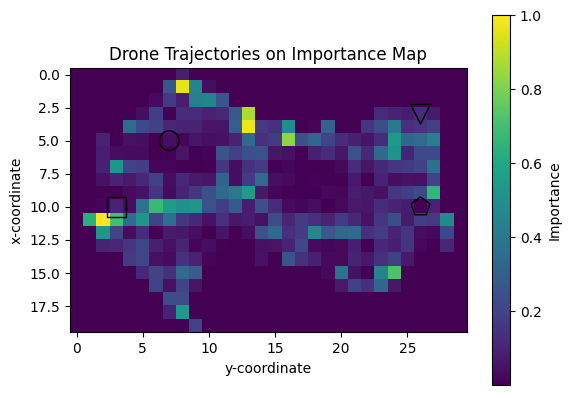

Length of drone state's vector: 4
What is inside: [[0.4, 0.7000000000000001, 0.7333333333333334, 1.8, np.float64(0.43603114484279887), np.float64(0.3252989860177903), np.float64(2.4395960646631174), np.float64(1.798423191283319), np.float64(0.12163848119122993), np.float64(1.0), np.float64(0.94375), np.float64(1.0), np.float64(0.9608695652173914)], [0.30000000000000004, 2.5, 0.7666666666666667, 1.2000000000000002, np.float64(9.999999999999999e-06), np.float64(1.4678664763107874), np.float64(0.5122768756109928), np.float64(0.7043524045981536), np.float64(0.09524251011163921), np.float64(1.0), np.float64(0.9470588235294118), np.float64(1.0), np.float64(0.82)], [0.9, 0.30000000000000004, 0.5666666666666668, 1.9333333333333333, np.float64(1.9531764075059486), np.float64(0.7460576923451817), np.float64(0.8787530543334955), np.float64(0.8728840749623273), np.float64(0.033934348419823256), np.float64(1.0), np.float64(0.9181818181818181), np.float64(1.0), np.float64(0.9666666666666667)], [1.0,

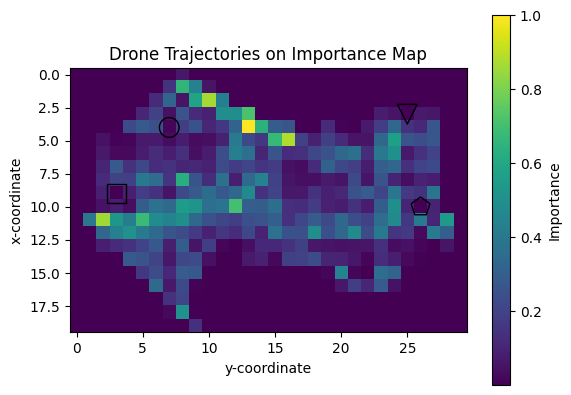

Length of drone state's vector: 4
What is inside: [[0.4, 0.8, 0.7000000000000001, 1.8, np.float64(2.640861141809352), np.float64(0.9713460062112207), np.float64(0.12466130119285303), np.float64(1.8184853651175936), np.float64(0.16293020211659232), np.float64(1.0), np.float64(0.94375), np.float64(0.890625), np.float64(0.9590909090909091)], [0.2, 2.5, 0.7666666666666667, 1.2333333333333334, np.float64(9.999999999999999e-06), np.float64(0.0908955150925659), np.float64(9.999999999999999e-06), np.float64(9.999999999999999e-06), np.float64(1e-06), np.float64(1.0), np.float64(0.901388888888889), np.float64(1.0), np.float64(0.82)], [0.8, 0.30000000000000004, 0.5666666666666668, 1.9666666666666668, np.float64(2.074973777918948), np.float64(0.0352099473735033), np.float64(0.9584686225305541), np.float64(1.0631604679910382), np.float64(0.15734180548663312), np.float64(1.0), np.float64(0.8520833333333333), np.float64(1.0), np.float64(0.9666666666666667)], [1.1, 2.6, 0.46666666666666673, 1.20000000

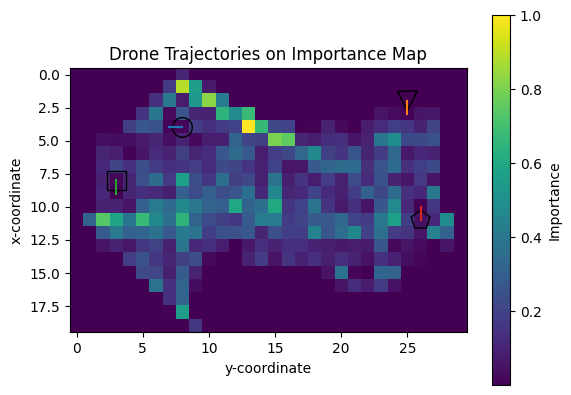

Length of drone state's vector: 4
What is inside: [[0.4, 0.7000000000000001, 0.7000000000000001, 1.8, np.float64(0.27089180869394236), np.float64(0.25558962293715765), np.float64(2.0149470144376256), np.float64(0.22219567915175736), np.float64(0.012204764704193745), np.float64(1.0), np.float64(0.93828125), np.float64(1.0), np.float64(0.9190217391304347)], [0.2, 2.6, 0.7666666666666667, 1.1666666666666667, np.float64(9.999999999999999e-06), np.float64(0.576627894415386), np.float64(1.2499999999999999e-06), np.float64(9.999999999999999e-06), np.float64(1e-06), np.float64(1.0), np.float64(0.8541666666666666), np.float64(0.9663461538461539), np.float64(0.775)], [0.8, 0.30000000000000004, 0.5666666666666668, 1.9333333333333333, np.float64(2.3757999504376284), np.float64(0.04803665014114274), np.float64(0.9676203187869936), np.float64(1.149828675627206), np.float64(0.01065277522835201), np.float64(1.0), np.float64(0.8466666666666667), np.float64(1.0), np.float64(0.9633333333333333)], [1.1, 2

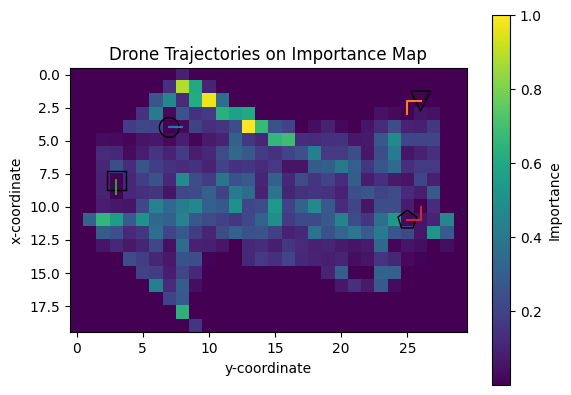

Length of drone state's vector: 4
What is inside: [[0.4, 0.7000000000000001, 0.7000000000000001, 1.8333333333333333, np.float64(0.293803096459573), np.float64(0.23498469224547103), np.float64(2.3393780003160205), np.float64(0.23436368825897907), np.float64(0.0012496899871713917), np.float64(1.0), np.float64(0.9375781249999999), np.float64(1.0), np.float64(0.9196195652173913)], [0.2, 2.7, 0.7666666666666667, 1.1666666666666667, np.float64(9.999999999999999e-06), np.float64(0.6778673296534252), np.float64(1.2499999999999999e-06), np.float64(9.999999999999999e-06), np.float64(1e-06), np.float64(1.0), np.float64(0.9500000000000001), np.float64(0.936111111111111), np.float64(0.7000000000000001)], [0.8, 0.2, 0.5666666666666668, 2.0, np.float64(1.5292221672213189), np.float64(1.2157381195192343), np.float64(9.999999999999999e-06), np.float64(0.034812093462824656), np.float64(0.10126576987814696), np.float64(1.0), np.float64(0.9249999999999999), np.float64(1.0), np.float64(0.933392857142857)],

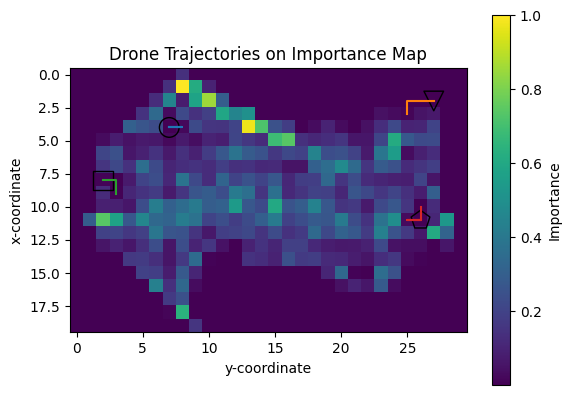

Length of drone state's vector: 4
What is inside: [[0.5, 0.7000000000000001, 0.7000000000000001, 1.8, np.float64(0.03218106714124392), np.float64(0.9525434896520515), np.float64(0.6819697254247401), np.float64(0.8649064537906903), np.float64(0.05237291979906553), np.float64(0.80525), np.float64(0.94), np.float64(1.0), np.float64(0.9608695652173914)], [0.2, 2.6, 0.8, 1.1666666666666667, np.float64(9.999999999999999e-06), np.float64(0.5333949372736322), np.float64(1.75e-06), np.float64(1.2499999999999999e-06), np.float64(1.25e-07), np.float64(1.0), np.float64(0.8370833333333333), np.float64(0.9682692307692308), np.float64(0.534375)], [0.9, 0.2, 0.5666666666666668, 1.9666666666666668, np.float64(0.11441421381022965), np.float64(1.2104302604394266), np.float64(9.999999999999999e-06), np.float64(0.1112865349855764), np.float64(0.129594962685594), np.float64(0.9027777777777778), np.float64(0.9181818181818181), np.float64(1.0), np.float64(0.9392857142857143)], [1.0, 2.6, 0.5333333333333333, 1

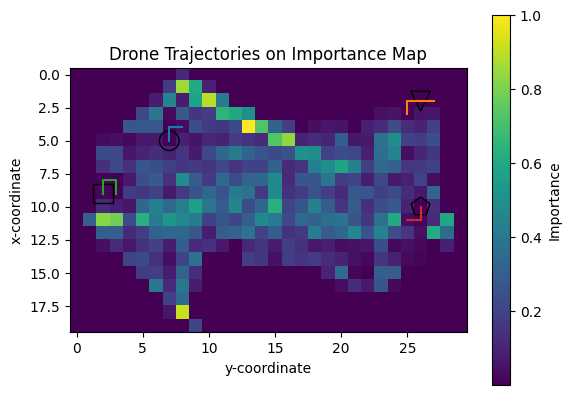

Length of drone state's vector: 4
What is inside: [[0.5, 0.6000000000000001, 0.7000000000000001, 1.8333333333333333, np.float64(2.6727625372573858), np.float64(2.009166618049782), np.float64(0.8372512796280294), np.float64(0.06044312752831318), np.float64(0.06037417740170705), np.float64(1.0), np.float64(0.94), np.float64(1.0), np.float64(0.9260416666666668)], [0.2, 2.6, 0.8, 1.1666666666666667, np.float64(9.999999999999999e-06), np.float64(0.2661704915396896), np.float64(1.9999999999999995e-06), np.float64(1.5e-06), np.float64(1.2500000000000003e-08), np.float64(1.0), np.float64(0.8369722222222222), np.float64(0.9692307692307692), np.float64(0.5378125)], [0.9, 0.30000000000000004, 0.5666666666666668, 1.9333333333333333, np.float64(0.07051682055490201), np.float64(1.0199303984597383), np.float64(0.2381147309457912), np.float64(1.2016209197089478), np.float64(0.008277117562735699), np.float64(0.8983333333333334), np.float64(0.9109090909090909), np.float64(0.7083333333333334), np.float64

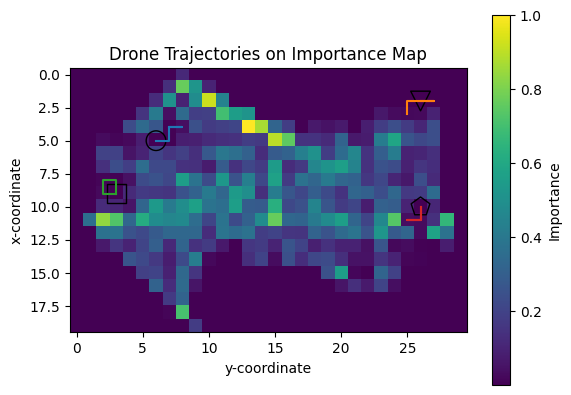

Length of drone state's vector: 4
What is inside: [[0.5, 0.7000000000000001, 0.7000000000000001, 1.8, np.float64(0.07514974755552736), np.float64(1.2857851240288203), np.float64(0.10630959313102786), np.float64(0.8914324830570655), np.float64(0.0054213848343935825), np.float64(0.81525), np.float64(0.9341666666666666), np.float64(0.875), np.float64(0.9570652173913043)], [0.1, 2.6, 0.8333333333333335, 1.1666666666666667, np.float64(9.999999999999999e-06), np.float64(2.6250000000000003e-07), np.float64(9.999999999999999e-06), np.float64(9.999999999999999e-06), np.float64(1e-06), np.float64(1.0), np.float64(0.7978552631578948), np.float64(1.0), np.float64(0.775)], [0.9, 0.2, 0.5666666666666668, 1.9666666666666668, np.float64(0.24459331021030778), np.float64(1.4833374259329948), np.float64(9.999999999999999e-06), np.float64(0.022141471646256503), np.float64(0.015675527444359127), np.float64(0.9083333333333334), np.float64(0.9102272727272727), np.float64(1.0), np.float64(0.930625)], [1.1, 2.

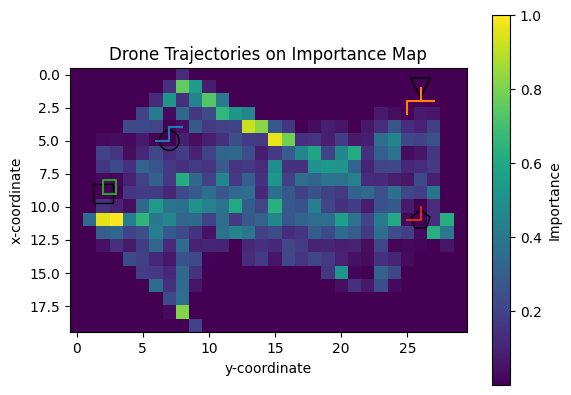

Length of drone state's vector: 4
What is inside: [[0.5, 0.8, 0.7000000000000001, 1.8333333333333333, np.float64(0.44792543727937206), np.float64(1.4845378569917096), np.float64(0.013823662216436279), np.float64(0.2989867462699288), np.float64(0.07543738744975975), np.float64(0.85), np.float64(0.94), np.float64(0.7734375), np.float64(0.9590909090909091)], [0.2, 2.6, 0.8, 1.2333333333333334, np.float64(1.2499999999999999e-06), np.float64(0.804189459447952), np.float64(2.4999999999999994e-06), np.float64(1.9999999999999995e-06), np.float64(2.6250000000000003e-08), np.float64(0.5625), np.float64(0.8353638888888889), np.float64(0.9711538461538461), np.float64(0.5506562500000001)], [0.9, 0.30000000000000004, 0.5666666666666668, 2.0, np.float64(0.08555795688879994), np.float64(0.8585840556078896), np.float64(0.0537501713160523), np.float64(1.858320767691073), np.float64(0.003122554222599716), np.float64(0.9038888888888889), np.float64(0.9095), np.float64(0.6791666666666667), np.float64(0.963

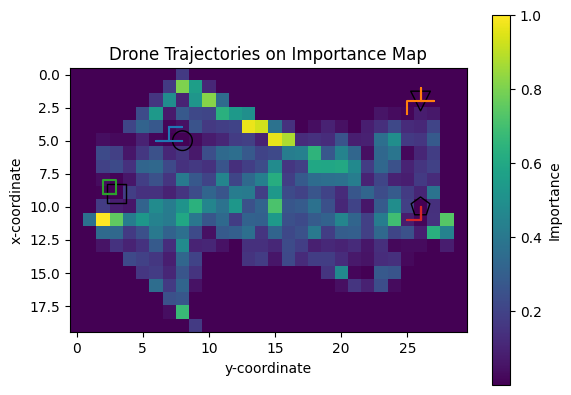

Length of drone state's vector: 4
What is inside: [[0.5, 0.8, 0.7000000000000001, 1.866666666666667, np.float64(0.48127784485084424), np.float64(1.2654714501797377), np.float64(0.0185990648481473), np.float64(0.480816773128323), np.float64(0.0073374095669580825), np.float64(0.8550000000000001), np.float64(0.9339999999999999), np.float64(0.7796875), np.float64(0.955)], [0.30000000000000004, 2.6, 0.7666666666666667, 1.2666666666666666, np.float64(2.7625e-07), np.float64(1.3111403468867542), np.float64(0.19964570776296223), np.float64(0.4569673184079582), np.float64(0.08398488512356228), np.float64(0.3925416666666666), np.float64(0.7814073529411765), np.float64(0.9730769230769231), np.float64(0.775)], [0.9, 0.4, 0.5666666666666668, 2.0, np.float64(0.36309338493518195), np.float64(0.33953685837871894), np.float64(0.013804758398466007), np.float64(1.264994961306809), np.float64(0.1333708267160002), np.float64(1.0), np.float64(0.9181818181818181), np.float64(0.523), np.float64(0.930769230769

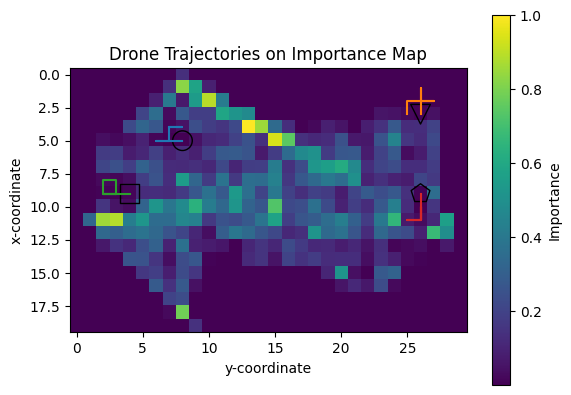

Length of drone state's vector: 4
What is inside: [[0.5, 0.7000000000000001, 0.7000000000000001, 1.8333333333333333, np.float64(0.20447998712882615), np.float64(1.6024818117183945), np.float64(0.13788773256667175), np.float64(0.02646369344563292), np.float64(0.003514017347874643), np.float64(0.83025), np.float64(0.93375), np.float64(0.8857142857142858), np.float64(0.914836956521739)], [0.4, 2.6, 0.7333333333333334, 1.2000000000000002, np.float64(0.11610613384231039), np.float64(1.9230172417168143), np.float64(1.7216394733497484), np.float64(2.298496081604945), np.float64(0.1316478695518027), np.float64(0.33815625), np.float64(0.7724328125), np.float64(0.9404326923076923), np.float64(0.775)], [0.8, 0.4, 0.6000000000000001, 1.9333333333333333, np.float64(1.1651901108495184), np.float64(0.1571402516429776), np.float64(0.20247189650936206), np.float64(2.422970484212929), np.float64(0.09266166049237565), np.float64(1.0), np.float64(0.8520833333333333), np.float64(0.60875), np.float64(0.9653

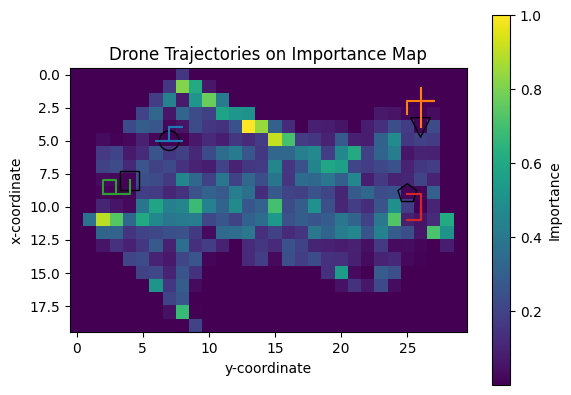

Length of drone state's vector: 4
What is inside: [[0.6000000000000001, 0.7000000000000001, 0.7000000000000001, 1.8333333333333333, np.float64(0.008793171874140998), np.float64(1.6761890068827137), np.float64(2.770948521947365), np.float64(1.5863034755164283), np.float64(0.14842423641384078), np.float64(0.7012499999999999), np.float64(0.9357142857142857), np.float64(1.0), np.float64(0.9608695652173914)], [0.4, 2.5, 0.7666666666666667, 1.2333333333333334, np.float64(0.3238354421563197), np.float64(2.1083027142478126), np.float64(2.8652331802194504), np.float64(0.16960395531223144), np.float64(0.17759910824373576), np.float64(0.6687500000000001), np.float64(0.838125), np.float64(0.9400499999999999), np.float64(0.645)], [0.8, 0.5, 0.6333333333333333, 1.9000000000000001, np.float64(2.5592145167295715), np.float64(1.696891639879896), np.float64(0.0613821426870846), np.float64(2.259329652076983), np.float64(0.20323973524850197), np.float64(1.0), np.float64(0.9249999999999999), np.float64(0.5

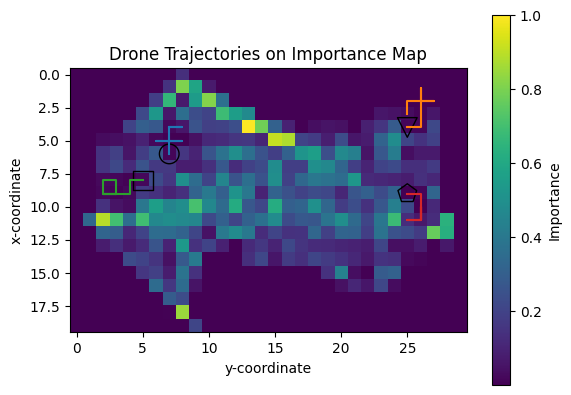

Length of drone state's vector: 4
What is inside: [[0.6000000000000001, 0.6000000000000001, 0.6666666666666667, 1.8333333333333333, np.float64(0.23325362479138187), np.float64(2.1433413651254836), np.float64(1.3400972995177285), np.float64(0.15641528172891242), np.float64(0.24721849982644636), np.float64(0.875), np.float64(0.9357142857142857), np.float64(1.0), np.float64(0.9260416666666668)], [0.30000000000000004, 2.5, 0.7666666666666667, 1.2000000000000002, np.float64(3.5000000000000004e-06), np.float64(0.27926344372178374), np.float64(0.4468482741395631), np.float64(0.14693576200266695), np.float64(0.030173864307692005), np.float64(0.7833333333333333), np.float64(0.7423529411764707), np.float64(1.0), np.float64(0.642)], [0.9, 0.5, 0.5666666666666668, 1.866666666666667, np.float64(0.28074156067164185), np.float64(3.338702742959972), np.float64(0.35695229089367664), np.float64(1.969533292350615), np.float64(0.1994994213823747), np.float64(0.9027777777777778), np.float64(0.9181818181818

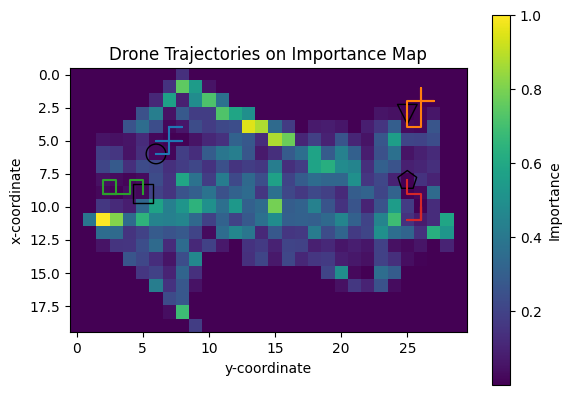

Length of drone state's vector: 4
What is inside: [[0.6000000000000001, 0.6000000000000001, 0.7000000000000001, 1.8, np.float64(0.2636037127019813), np.float64(2.4593056128130772), np.float64(1.4923003939966017), np.float64(0.13447599008131447), np.float64(0.020766949333543276), np.float64(0.8791666666666668), np.float64(0.9292857142857143), np.float64(1.0), np.float64(0.9233333333333333)], [0.30000000000000004, 2.4000000000000004, 0.8, 1.2000000000000002, np.float64(9.999999999999999e-06), np.float64(2.9206043879411103), np.float64(0.7587459769858874), np.float64(0.04560635547477005), np.float64(0.03375955227346254), np.float64(1.0), np.float64(0.9470588235294118), np.float64(1.0), np.float64(0.5599999999999999)], [0.9, 0.5, 0.6000000000000001, 1.8333333333333333, np.float64(0.42307089923599894), np.float64(4.018226725932687), np.float64(0.42504730095621607), np.float64(1.8366144586310598), np.float64(0.023283267053621506), np.float64(0.9055555555555556), np.float64(0.91), np.float64(

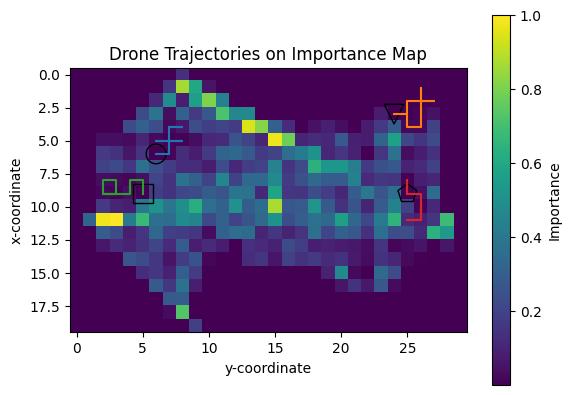

Length of drone state's vector: 4
What is inside: [[0.7000000000000001, 0.6000000000000001, 0.7000000000000001, 1.8, np.float64(0.0504309758802484), np.float64(2.1463776781740855), np.float64(2.5509019710246887), np.float64(1.1067093393676772), np.float64(0.14515098823987138), np.float64(0.7621428571428571), np.float64(0.9307692307692308), np.float64(1.0), np.float64(0.9625)], [0.30000000000000004, 2.4000000000000004, 0.8333333333333335, 1.2000000000000002, np.float64(9.999999999999999e-06), np.float64(2.3428916505494137), np.float64(0.6113836539834157), np.float64(0.07044976643363926), np.float64(0.0037321848577019498), np.float64(1.0), np.float64(0.9417647058823528), np.float64(1.0), np.float64(0.5533333333333333)], [0.9, 0.4, 0.6333333333333333, 1.866666666666667, np.float64(0.08963653351842356), np.float64(0.35282205165878355), np.float64(0.08726268263076072), np.float64(0.04593041497822393), np.float64(0.029986594674844044), np.float64(0.911111111111111), np.float64(0.910909090909

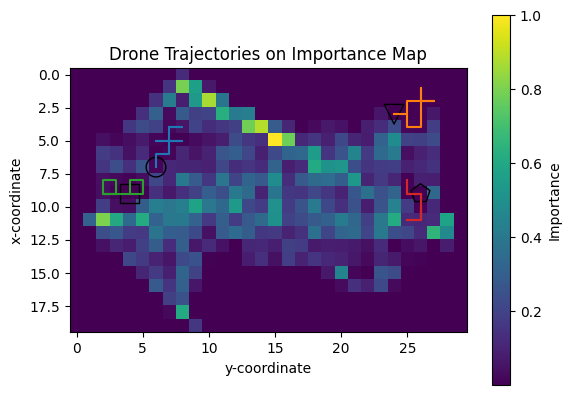

Length of drone state's vector: 4
What is inside: [[0.7000000000000001, 0.6000000000000001, 0.7666666666666667, 1.7666666666666668, np.float64(0.13078913226307537), np.float64(3.6244908080458633), np.float64(2.209649674895868), np.float64(1.2486321211509495), np.float64(0.021500724369352665), np.float64(0.7692857142857142), np.float64(0.9238461538461539), np.float64(1.0), np.float64(0.9587499999999999)], [0.4, 2.4000000000000004, 0.8666666666666667, 1.1666666666666667, np.float64(0.009258076747270295), np.float64(5.054303871763482), np.float64(1.3870464661680102), np.float64(0.430979604268779), np.float64(0.1938147453172016), np.float64(0.75875), np.float64(0.94375), np.float64(0.9458854166666667), np.float64(0.5875)], [1.0, 0.4, 0.6666666666666667, 1.8333333333333333, np.float64(0.061703357845742865), np.float64(2.38651097331646), np.float64(0.7009424030962373), np.float64(3.4066008421396683), np.float64(0.05012852319731821), np.float64(0.827), np.float64(0.9099999999999999), np.float

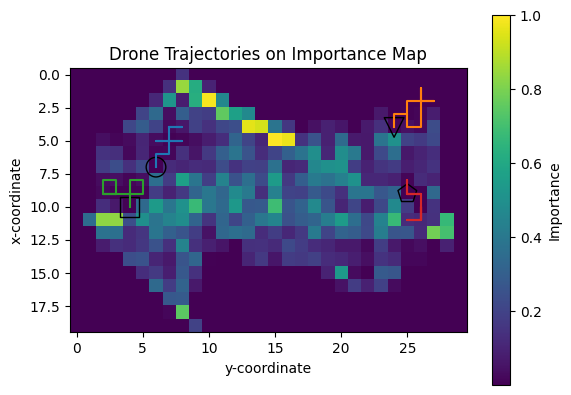

Length of drone state's vector: 4
What is inside: [[0.7000000000000001, 0.7000000000000001, 0.7666666666666667, 1.7666666666666668, np.float64(0.18905609984757527), np.float64(2.1132199161591907), np.float64(0.09055894501525046), np.float64(1.0489681515048124), np.float64(0.15173972064137034), np.float64(0.6689285714285713), np.float64(0.9307692307692308), np.float64(0.8621428571428572), np.float64(0.9608695652173914)], [0.30000000000000004, 2.4000000000000004, 0.9, 1.2000000000000002, np.float64(9.999999999999999e-06), np.float64(0.26466664168022436), np.float64(0.7326393852140135), np.float64(0.10917907098731017), np.float64(0.0011954615853528318), np.float64(1.0), np.float64(0.8899117647058823), np.float64(1.0), np.float64(0.5689166666666666)], [1.0, 0.4, 0.6666666666666667, 1.866666666666667, np.float64(0.1295064120749996), np.float64(3.963575307435965), np.float64(0.4436927405372959), np.float64(3.224189183624408), np.float64(0.003629646611226683), np.float64(0.8320000000000001), 

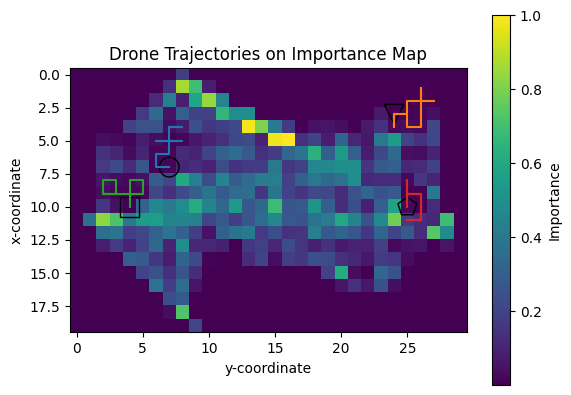

Length of drone state's vector: 4
What is inside: [[0.7000000000000001, 0.7000000000000001, 0.8, 1.7666666666666668, np.float64(0.2750677329637491), np.float64(1.821919746112364), np.float64(0.10231059178264648), np.float64(0.8440201111916188), np.float64(0.01235433244341369), np.float64(0.6796428571428572), np.float64(0.9238461538461539), np.float64(0.8657142857142857), np.float64(0.9569565217391304)], [0.30000000000000004, 2.5, 0.9333333333333335, 1.1666666666666667, np.float64(4.750000000000001e-06), np.float64(0.378817644051962), np.float64(0.010064681317073453), np.float64(0.21393195560698838), np.float64(0.00710142061844179), np.float64(0.8250000000000001), np.float64(0.7127264705882354), np.float64(0.96114), np.float64(0.6627)], [1.1, 0.4, 0.6666666666666667, 1.866666666666667, np.float64(0.02073011249311596), np.float64(2.239986950271713), np.float64(8.395390343869927), np.float64(5.734411593880021), np.float64(0.44210920355619987), np.float64(0.7640909090909092), np.float64(0.

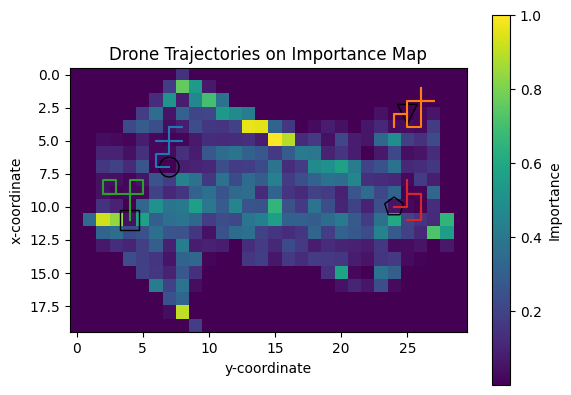

Length of drone state's vector: 4
What is inside: [[0.7000000000000001, 0.6000000000000001, 0.7333333333333334, 1.7333333333333334, np.float64(0.2763684474242103), np.float64(3.115899479489976), np.float64(3.54383004372743), np.float64(0.05900195262183909), np.float64(0.0148045966946967), np.float64(0.7907142857142857), np.float64(0.9235384615384615), np.float64(1.0), np.float64(0.918375)], [0.2, 2.5, 0.9, 1.1, np.float64(9.999999999999999e-06), np.float64(0.035537114364362014), np.float64(9.999999999999999e-06), np.float64(2.5262499999999997e-06), np.float64(4.7500000000000016e-07), np.float64(1.0), np.float64(0.6841027777777778), np.float64(1.0), np.float64(0.550025)], [1.1, 0.30000000000000004, 0.6000000000000001, 1.8333333333333333, np.float64(0.5603425345737748), np.float64(3.0627629451837093), np.float64(8.783646936364475), np.float64(0.4636208974853312), np.float64(0.7396170297669257), np.float64(0.8763181818181818), np.float64(0.8999999999999999), np.float64(1.0), np.float64(0.

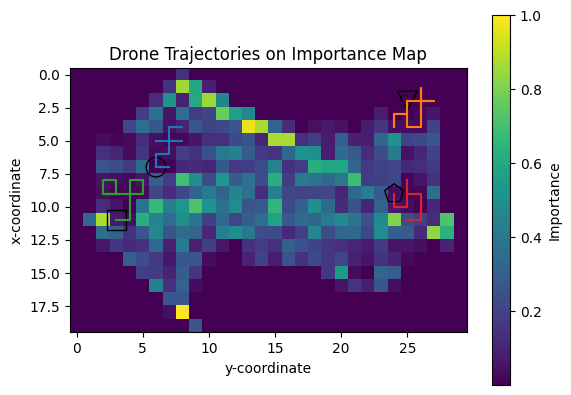

Length of drone state's vector: 4
What is inside: [[0.7000000000000001, 0.6000000000000001, 0.8, 1.7000000000000002, np.float64(0.4218631032140844), np.float64(2.936692904773404), np.float64(3.178945247861785), np.float64(0.08243346073177706), np.float64(0.0012929849448232908), np.float64(0.7978571428571428), np.float64(0.9231230769230769), np.float64(1.0), np.float64(0.9191916666666667)], [0.30000000000000004, 2.5, 0.9333333333333335, 1.0666666666666667, np.float64(7.25e-07), np.float64(0.4719754770443118), np.float64(0.022446243593972265), np.float64(0.1808906615218241), np.float64(0.0024905125678580465), np.float64(0.6908333333333333), np.float64(0.726864705882353), np.float64(0.9631399999999999), np.float64(0.67077)], [1.2000000000000002, 0.30000000000000004, 0.6333333333333333, 1.8, np.float64(0.7482645742018706), np.float64(1.2513674018673517), np.float64(3.001198995005618), np.float64(2.2428739740527175), np.float64(0.32877586498640676), np.float64(0.817875), np.float64(0.8875),

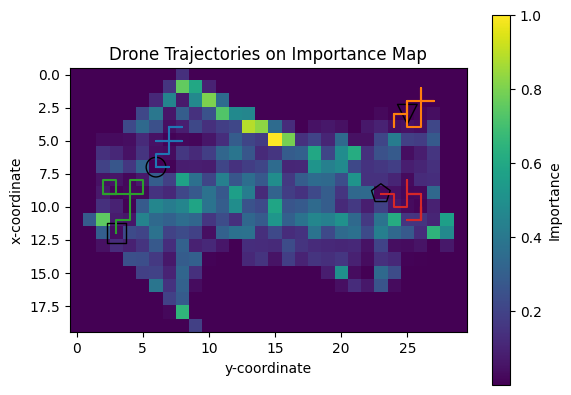

Length of drone state's vector: 4
What is inside: [[0.6000000000000001, 0.6000000000000001, 0.8333333333333335, 1.666666666666667, np.float64(0.31184565621804555), np.float64(0.049268951152132805), np.float64(1.2363070207381723), np.float64(0.3152466644310271), np.float64(0.03180087795462029), np.float64(0.9083333333333333), np.float64(0.8601142857142856), np.float64(1.0), np.float64(0.930875)], [0.30000000000000004, 2.4000000000000004, 0.9333333333333335, 1.0666666666666667, np.float64(9.999999999999999e-06), np.float64(0.5430414531772836), np.float64(0.6252005488490175), np.float64(0.015301076202456439), np.float64(0.002751207479670401), np.float64(1.0), np.float64(0.7975205882352941), np.float64(1.0), np.float64(0.5686166666666667)], [1.3, 0.30000000000000004, 0.6000000000000001, 1.7666666666666668, np.float64(0.32035903679734107), np.float64(9.999999999999999e-06), np.float64(0.6059185193088198), np.float64(1.2076930491197553), np.float64(0.12708645754507403), np.float64(0.77034615

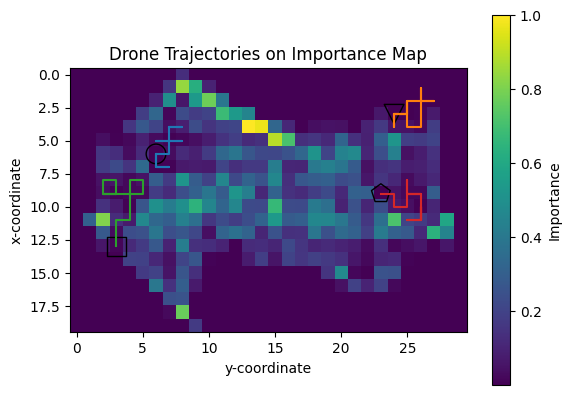

Length of drone state's vector: 4
What is inside: [[0.6000000000000001, 0.5, 0.8666666666666667, 1.666666666666667, np.float64(1.0138241540247572), np.float64(3.142292231252246), np.float64(0.49787038544740675), np.float64(0.07134461052594318), np.float64(0.11652095813361998), np.float64(1.0), np.float64(0.8328571428571429), np.float64(1.0), np.float64(0.89964)], [0.4, 2.4000000000000004, 0.9333333333333335, 1.0333333333333334, np.float64(0.015998926539713416), np.float64(6.56840275091988), np.float64(1.416292102051921), np.float64(0.7569878987810725), np.float64(0.060526210232012545), np.float64(0.7582125), np.float64(0.83734375), np.float64(0.9583854166666667), np.float64(0.6245833333333334)], [1.4000000000000001, 0.30000000000000004, 0.6000000000000001, 1.7333333333333334, np.float64(0.16802965177359935), np.float64(9.999999999999999e-06), np.float64(9.999999999999999e-06), np.float64(2.7336325762108653), np.float64(1e-06), np.float64(0.7313928571428573), np.float64(0.85), np.float6

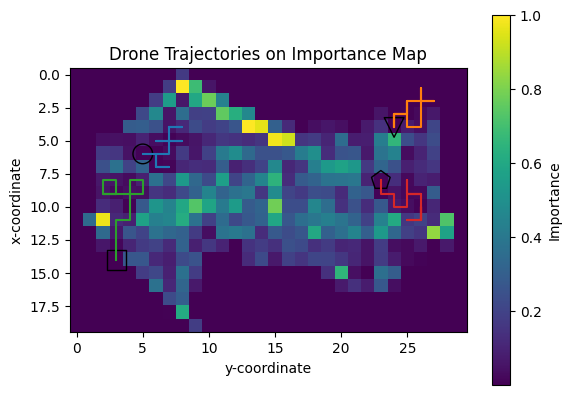

Length of drone state's vector: 4
What is inside: [[0.5, 0.5, 0.8666666666666667, 1.666666666666667, np.float64(2.31125684810672), np.float64(0.08198395276539762), np.float64(0.3773611026442899), np.float64(0.1898923489936974), np.float64(0.0724974991291526), np.float64(1.0), np.float64(0.789), np.float64(1.0), np.float64(0.88965)], [0.4, 2.4000000000000004, 0.9, 1.0333333333333334, np.float64(0.023538612790122232), np.float64(4.092053971037003), np.float64(0.9902253000125596), np.float64(0.3732312756341047), np.float64(0.004171969805078282), np.float64(0.7644625), np.float64(0.839203125), np.float64(0.96046875), np.float64(0.6295416666666667)], [1.3, 0.30000000000000004, 0.6000000000000001, 1.7333333333333334, np.float64(0.38409834965571604), np.float64(1.2499999999999999e-06), np.float64(0.49699561192949826), np.float64(0.6903636518648053), np.float64(0.013986308137868659), np.float64(0.7857307692307691), np.float64(0.7339285714285715), np.float64(1.0), np.float64(0.9634259259259259)

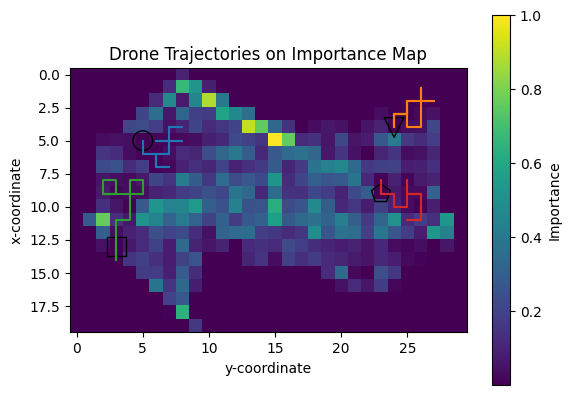

Length of drone state's vector: 4
What is inside: [[0.5, 0.5, 0.8333333333333335, 1.6, np.float64(2.489354307740243), np.float64(0.15095577896410137), np.float64(0.303613560798219), np.float64(0.26487693834664416), np.float64(0.008812172271827845), np.float64(1.0), np.float64(0.788), np.float64(1.0), np.float64(0.88905)], [0.30000000000000004, 2.4000000000000004, 0.9, 0.9666666666666667, np.float64(9.999999999999999e-06), np.float64(0.06183209403592882), np.float64(0.6920027543737839), np.float64(0.0809589581147471), np.float64(0.002352475549890365), np.float64(1.0), np.float64(0.794590294117647), np.float64(1.0), np.float64(0.5932725)], [1.3, 0.2, 0.5666666666666668, 1.7000000000000002, np.float64(3.8304567873456112), np.float64(9.999999999999999e-06), np.float64(9.999999999999999e-06), np.float64(0.04233590345225891), np.float64(0.05878958881587019), np.float64(0.9221153846153846), np.float64(0.8714285714285713), np.float64(1.0), np.float64(0.9334821428571428)], [0.9, 2.2, 0.70000000

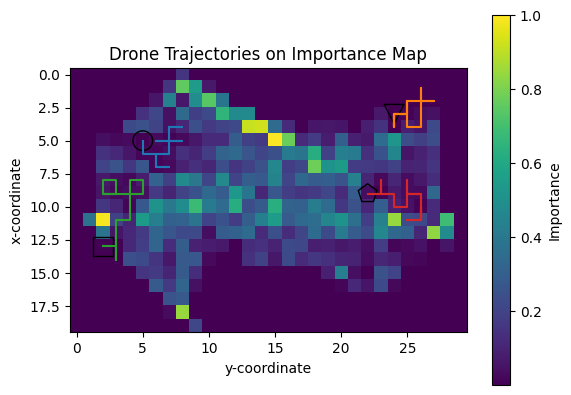

Length of drone state's vector: 4
What is inside: [[0.6000000000000001, 0.5, 0.8666666666666667, 1.6333333333333333, np.float64(0.04030081395022815), np.float64(2.8302447093816765), np.float64(0.46873254988215923), np.float64(0.29793507690502724), np.float64(0.019158257149228503), np.float64(0.8391666666666667), np.float64(0.8375), np.float64(1.0), np.float64(0.90224)], [0.30000000000000004, 2.5, 0.9666666666666667, 0.9666666666666667, np.float64(1.9749999999999997e-06), np.float64(0.7216853914975646), np.float64(0.012525262129623242), np.float64(0.45869470105047805), np.float64(0.008107765671784612), np.float64(0.7324999999999999), np.float64(0.7640138235294117), np.float64(0.9612314000000001), np.float64(0.697077)], [1.3, 0.2, 0.6333333333333333, 1.7333333333333334, np.float64(3.0791490963766686), np.float64(9.999999999999999e-06), np.float64(9.999999999999999e-06), np.float64(0.10295481726944229), np.float64(0.007336498573745515), np.float64(0.9259615384615384), np.float64(0.8585714

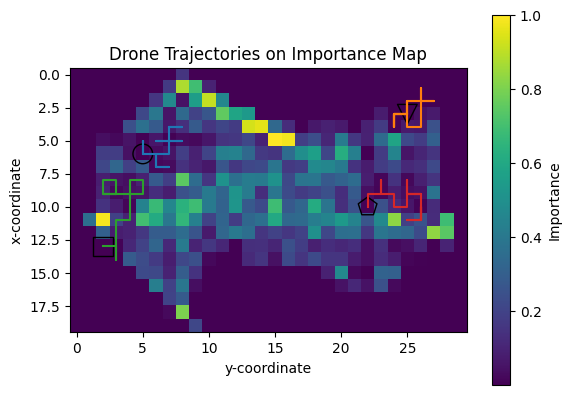

Length of drone state's vector: 4
What is inside: [[0.7000000000000001, 0.5, 0.8666666666666667, 1.6, np.float64(0.05393305201663029), np.float64(0.9767435856046134), np.float64(1.4883514079031677), np.float64(0.24471072991833415), np.float64(0.25052209024718103), np.float64(0.7285714285714285), np.float64(0.8353846153846154), np.float64(1.0), np.float64(0.898424)], [0.30000000000000004, 2.4000000000000004, 1.0, 0.9666666666666667, np.float64(9.999999999999999e-06), np.float64(0.14599731788285258), np.float64(0.3303575533126745), np.float64(0.015585031001802264), np.float64(0.0009175965914823954), np.float64(1.0), np.float64(0.8032546176470587), np.float64(1.0), np.float64(0.5897439166666667)], [1.4000000000000001, 0.2, 0.6333333333333333, 1.7000000000000002, np.float64(0.016181625040635052), np.float64(9.999999999999999e-06), np.float64(9.999999999999999e-06), np.float64(1.9999999999999995e-06), np.float64(1e-06), np.float64(0.8658928571428571), np.float64(0.85), np.float64(1.0), np.f

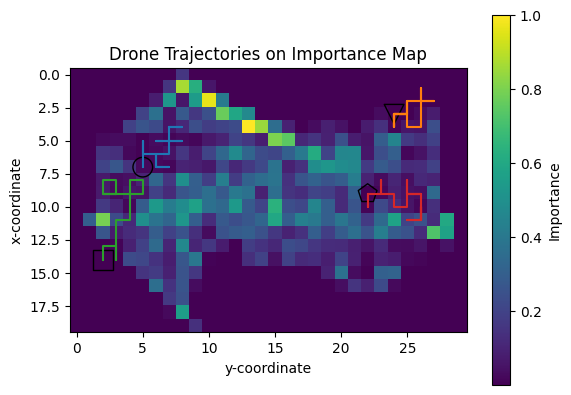

Length of drone state's vector: 4
What is inside: [[0.6000000000000001, 0.5, 0.9333333333333335, 1.6333333333333333, np.float64(0.08401579819096516), np.float64(0.22597737227603631), np.float64(0.503338949520433), np.float64(0.2960210983908051), np.float64(0.005142035113047196), np.float64(0.8475), np.float64(0.7813571428571429), np.float64(1.0), np.float64(0.9057999999999999)], [0.30000000000000004, 2.5, 1.0333333333333334, 0.9666666666666667, np.float64(2.4749999999999996e-06), np.float64(0.7708988646175208), np.float64(0.008998682451678838), np.float64(0.31833962128997445), np.float64(0.0029098970854430327), np.float64(0.7491666666666666), np.float64(0.7783169705882352), np.float64(0.96112314), np.float64(0.7057077)], [1.5, 0.2, 0.6333333333333333, 1.7333333333333334, np.float64(1.2499999999999999e-06), np.float64(9.999999999999999e-06), np.float64(9.999999999999999e-06), np.float64(9.999999999999999e-06), np.float64(1e-06), np.float64(0.8215000000000001), np.float64(0.82), np.float

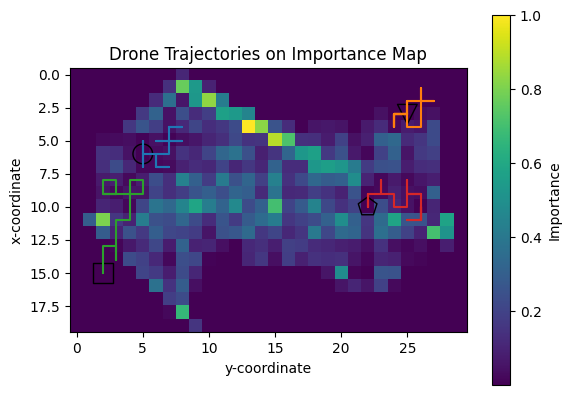

Length of drone state's vector: 4
What is inside: [[0.6000000000000001, 0.5, 0.9333333333333335, 1.6333333333333333, np.float64(0.08725920282485254), np.float64(0.3606004775699633), np.float64(0.4003509549063284), np.float64(0.24107343384005653), np.float64(0.0003450181553688638), np.float64(0.8516666666666667), np.float64(0.7864571428571429), np.float64(1.0), np.float64(0.907656)], [0.30000000000000004, 2.6, 1.0333333333333334, 0.9333333333333335, np.float64(4.776250000000002e-06), np.float64(0.6022669179467863), np.float64(0.01297886693714329), np.float64(0.48639201896632567), np.float64(0.03148419972019024), np.float64(0.6925416666666667), np.float64(0.8180250000000001), np.float64(0.9262160384615385), np.float64(0.763125)], [1.5, 0.1, 0.6333333333333333, 1.7666666666666668, np.float64(9.999999999999999e-06), np.float64(9.999999999999999e-06), np.float64(9.999999999999999e-06), np.float64(1.2499999999999999e-06), np.float64(1e-06), np.float64(1.0), np.float64(0.82), np.float64(1.0),

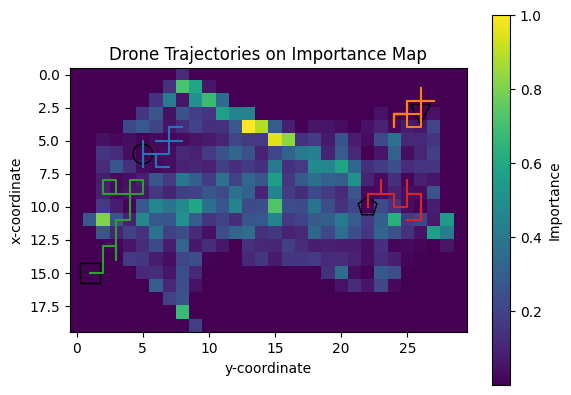

Length of drone state's vector: 4
What is inside: [[0.6000000000000001, 0.6000000000000001, 0.8666666666666667, 1.6333333333333333, np.float64(0.4385152760189937), np.float64(0.3741671301042926), np.float64(0.023132767557647253), np.float64(0.49972248734082525), np.float64(0.028984087309007006), np.float64(0.9416666666666668), np.float64(0.8746214285714285), np.float64(0.8375666666666667), np.float64(0.9393375)], [0.30000000000000004, 2.6, 0.9666666666666667, 0.9666666666666667, np.float64(5.026250000000002e-06), np.float64(0.6195823801723592), np.float64(0.029493068311087986), np.float64(0.4063756463667931), np.float64(0.002988481073197433), np.float64(0.7092083333333336), np.float64(0.8211279411764706), np.float64(0.9281391153846154), np.float64(0.7513125)], [1.4000000000000001, 0.1, 0.6000000000000001, 1.8, np.float64(9.999999999999999e-06), np.float64(1.2499999999999999e-06), np.float64(9.999999999999999e-06), np.float64(1.75e-06), np.float64(1e-06), np.float64(1.0), np.float64(0.7

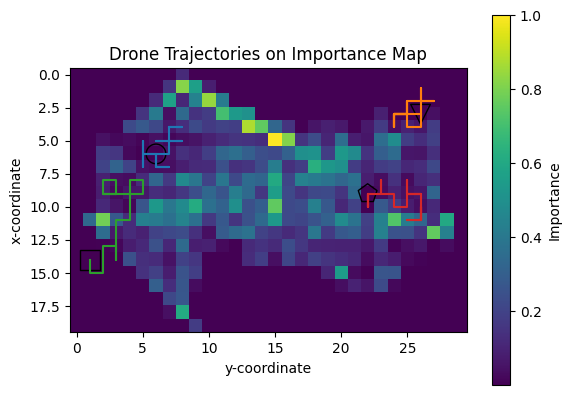

Length of drone state's vector: 4
What is inside: [[0.6000000000000001, 0.5, 0.8333333333333335, 1.6333333333333333, np.float64(0.10723786757724504), np.float64(0.45579931064233214), np.float64(0.3422615638641455), np.float64(0.09454277861510013), np.float64(0.0024635117783262453), np.float64(0.86), np.float64(0.7973242857142857), np.float64(1.0), np.float64(0.9038656)], [0.4, 2.6, 0.9, 0.9333333333333335, np.float64(0.016477863775212195), np.float64(1.1468228971690024), np.float64(0.876068172682221), np.float64(2.2861903515567934), np.float64(0.06103171688624448), np.float64(0.5519687500000002), np.float64(0.8458703125), np.float64(0.9280192307692309), np.float64(0.7637499999999999)], [1.3, 0.1, 0.6000000000000001, 1.7666666666666668, np.float64(9.999999999999999e-06), np.float64(1.2499999999999999e-06), np.float64(9.999999999999999e-06), np.float64(0.06145711531406992), np.float64(1e-06), np.float64(1.0), np.float64(0.625), np.float64(1.0), np.float64(0.9111206896551723)], [0.8, 2.2,

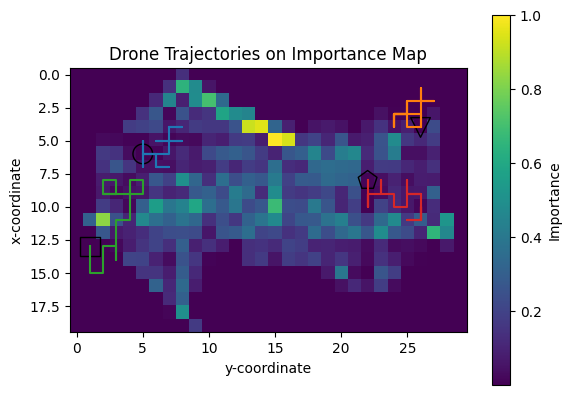

Length of drone state's vector: 4
What is inside: [[0.6000000000000001, 0.6000000000000001, 0.8, 1.6, np.float64(0.39468436766300824), np.float64(0.46132710944785293), np.float64(0.02713101079674627), np.float64(0.5552422109601156), np.float64(0.007754543302187186), np.float64(0.9500000000000001), np.float64(0.8771435714285715), np.float64(0.8379233333333334), np.float64(0.94080875)], [0.30000000000000004, 2.6, 0.9, 0.9333333333333335, np.float64(5.526250000000003e-06), np.float64(0.07927641080420009), np.float64(0.04943411686047766), np.float64(0.5338410520179114), np.float64(0.001479174136696132), np.float64(0.7425416666666669), np.float64(0.8021735294117648), np.float64(0.9319852692307692), np.float64(0.75075625)], [1.3, 0.0, 0.5666666666666668, 1.8, np.float64(9.999999999999999e-06), np.float64(9.999999999999999e-06), np.float64(0.0), np.float64(1.2499999999999999e-06), np.float64(1e-06), np.float64(1.0), np.float64(0.8714285714285713), 0.0, np.float64(0.8865833333333334)], [0.8, 2

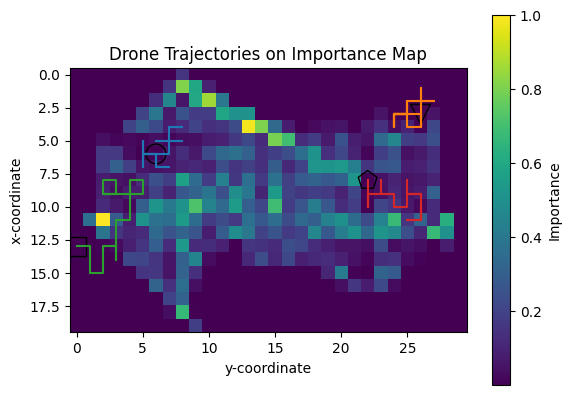

Length of drone state's vector: 4
What is inside: [[0.6000000000000001, 0.7000000000000001, 0.8666666666666667, 1.5666666666666667, np.float64(0.1824448898099505), np.float64(0.49948371311666784), np.float64(0.051725492709241136), np.float64(1.5715522892602034), np.float64(0.061164012132118944), np.float64(0.8679166666666668), np.float64(0.8869642857142858), np.float64(0.7259928571428571), np.float64(0.9590217391304349)], [0.30000000000000004, 2.5, 0.9666666666666667, 0.9666666666666667, np.float64(3.7250000000000003e-06), np.float64(0.8496608677345064), np.float64(0.03843453513567051), np.float64(0.014771853566248902), np.float64(0.008624809983826186), np.float64(0.7908333333333334), np.float64(0.8154825794117648), np.float64(0.96612314), np.float64(0.60767577)], [1.4000000000000001, 0.0, 0.6000000000000001, 1.8, np.float64(1.2499999999999999e-06), np.float64(9.999999999999999e-06), np.float64(0.0), np.float64(1.75e-06), np.float64(1e-06), np.float64(0.9375), np.float64(0.85), 0.0, np

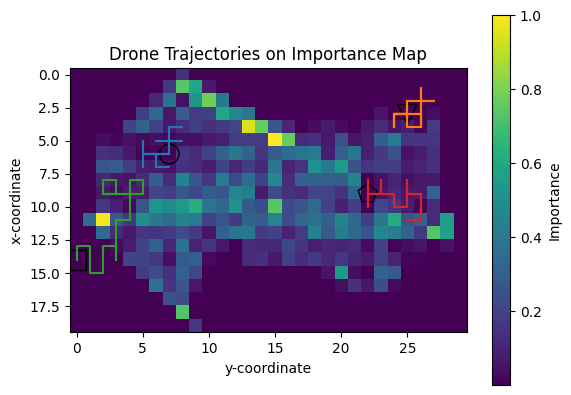

Length of drone state's vector: 4
What is inside: [[0.5, 0.7000000000000001, 0.8, 1.5666666666666667, np.float64(0.7601399615084887), np.float64(0.09064685539410361), np.float64(0.5088891649674985), np.float64(0.49705219009957174), np.float64(0.00921320287690449), np.float64(0.94025), np.float64(0.8347083333333333), np.float64(0.8550000000000001), np.float64(0.940788043478261)], [0.2, 2.5, 0.9, 0.9666666666666667, np.float64(9.999999999999999e-06), np.float64(0.01720017324182485), np.float64(9.999999999999999e-06), np.float64(6.026250000000002e-06), np.float64(3.7250000000000003e-07), np.float64(1.0), np.float64(0.7805807694444444), np.float64(1.0), np.float64(0.6879750000000001)], [1.4000000000000001, 0.0, 0.5, 1.8, np.float64(1.5e-06), np.float64(9.999999999999999e-06), np.float64(0.0), np.float64(1.9999999999999995e-06), np.float64(1.0000000000000002e-07), np.float64(0.9392857142857143), np.float64(0.835), 0.0, np.float64(0.8953333333333333)], [0.8, 2.2, 0.7000000000000001, 1.066666

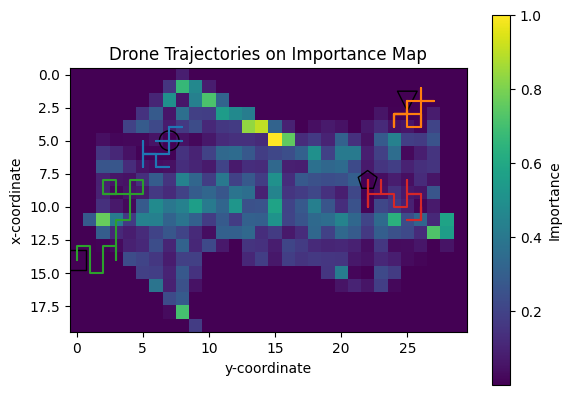

Length of drone state's vector: 4
What is inside: [[0.5, 0.8, 0.8, 1.5333333333333334, np.float64(1.525546399394008), np.float64(1.5996503586568238), np.float64(0.036799388829415), np.float64(0.37964410422732514), np.float64(0.05612749884875142), np.float64(0.975), np.float64(0.9372333333333334), np.float64(0.764140625), np.float64(0.9572045454545456)], [0.2, 2.4000000000000004, 0.9, 1.0, np.float64(9.999999999999999e-06), np.float64(0.07173241425222016), np.float64(9.999999999999999e-06), np.float64(6.225000000000001e-07), np.float64(1e-06), np.float64(1.0), np.float64(0.8086293611111112), np.float64(1.0), np.float64(0.6024791666666668)], [1.4000000000000001, 0.1, 0.5, 1.7666666666666668, np.float64(1.9999999999999995e-06), np.float64(2.4999999999999994e-06), np.float64(3.5000000000000004e-07), np.float64(3e-06), np.float64(2e-07), np.float64(0.9428571428571428), np.float64(0.7116666666666666), np.float64(0.035), np.float64(0.9213793103448276)], [0.8, 2.1, 0.7000000000000001, 1.1, np.

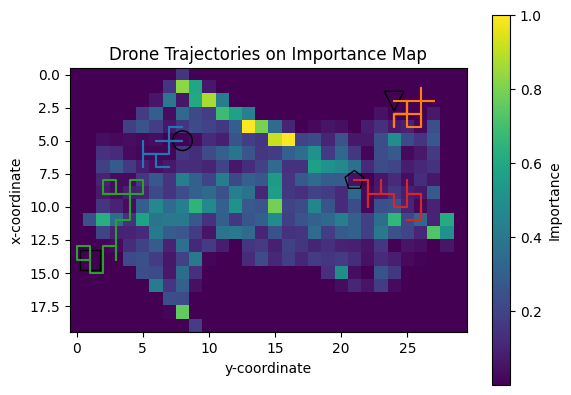

Length of drone state's vector: 4
What is inside: [[0.5, 0.7000000000000001, 0.7666666666666667, 1.5666666666666667, np.float64(0.7624541672111961), np.float64(0.16894698127278032), np.float64(0.552779759825295), np.float64(0.07722469137639713), np.float64(0.00138682207919222), np.float64(0.9502500000000002), np.float64(0.8383541666666666), np.float64(0.8692857142857144), np.float64(0.9170135869565218)], [0.2, 2.5, 0.8666666666666667, 0.9666666666666667, np.float64(9.999999999999999e-06), np.float64(0.04767657215821577), np.float64(1.2499999999999999e-06), np.float64(6.526250000000003e-06), np.float64(6.225000000000002e-08), np.float64(1.0), np.float64(0.7955238250000001), np.float64(0.965), np.float64(0.7017700000000001)], [1.3, 0.1, 0.5, 1.7666666666666668, np.float64(9.999999999999999e-06), np.float64(4.5e-07), np.float64(1.9999999999999995e-06), np.float64(0.14934810093684792), np.float64(2e-07), np.float64(1.0), np.float64(0.62), np.float64(0.19999999999999998), np.float64(0.91698

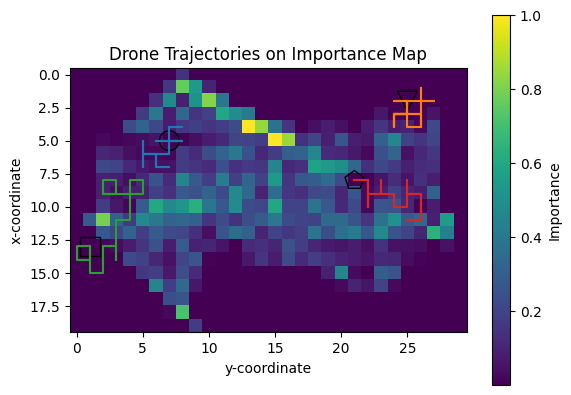

Length of drone state's vector: 4
What is inside: [[0.4, 0.7000000000000001, 0.7333333333333334, 1.5666666666666667, np.float64(0.9180364694451236), np.float64(0.014992542232926674), np.float64(2.3634297363530496), np.float64(1.7776702141346252), np.float64(0.09149593583634667), np.float64(1.0), np.float64(0.79533984375), np.float64(1.0), np.float64(0.8796684782608695)], [0.30000000000000004, 2.5, 0.7666666666666667, 0.9666666666666667, np.float64(3.1225000000000006e-07), np.float64(1.1543916715594316), np.float64(0.13173416674422514), np.float64(0.08928120787443138), np.float64(0.007026463482346694), np.float64(0.677075), np.float64(0.8447873755882354), np.float64(0.97012314), np.float64(0.627312077)], [1.2000000000000002, 0.1, 0.46666666666666673, 1.7666666666666668, np.float64(3.0895518116373233), np.float64(4.5e-07), np.float64(9.999999999999999e-06), np.float64(2.4132632390009907), np.float64(1e-06), np.float64(1.0), np.float64(0.5643750000000001), np.float64(1.0), np.float64(0.95

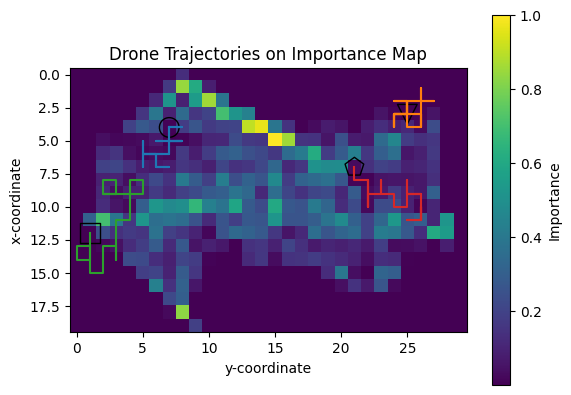

Length of drone state's vector: 4
What is inside: [[0.30000000000000004, 0.7000000000000001, 0.7333333333333334, 1.5, np.float64(4.374403982304752), np.float64(0.11342155175057482), np.float64(4.04688117913326), np.float64(2.6034557795959614), np.float64(0.07583662253795279), np.float64(1.0), np.float64(0.7603198529411765), np.float64(1.0), np.float64(0.8396464450000001)], [0.30000000000000004, 2.4000000000000004, 0.7333333333333334, 0.9333333333333335, np.float64(1.75e-06), np.float64(0.8572848263578292), np.float64(0.3517660822854477), np.float64(0.02314924185859584), np.float64(0.006248528717315128), np.float64(0.725), np.float64(0.8530916382352941), np.float64(0.9625), np.float64(0.5353113724999999)], [1.2000000000000002, 0.1, 0.43333333333333335, 1.7000000000000002, np.float64(3.1404535112627725), np.float64(7.000000000000001e-07), np.float64(9.999999999999999e-06), np.float64(2.889561135962577), np.float64(1.0000000000000002e-07), np.float64(1.0), np.float64(0.5625), np.float64(1

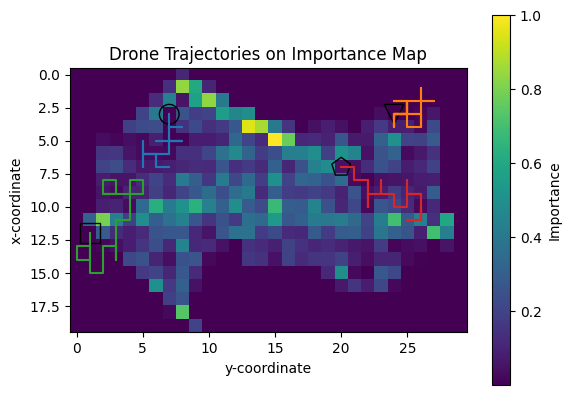

Length of drone state's vector: 4
What is inside: [[0.30000000000000004, 0.8, 0.7333333333333334, 1.4666666666666668, np.float64(0.6059906822842627), np.float64(1.764246533312019), np.float64(0.07888499426697881), np.float64(2.318803447876801), np.float64(0.30283458739292557), np.float64(1.0), np.float64(0.8960882352941177), np.float64(0.890625), np.float64(0.7948576470454545)], [0.30000000000000004, 2.3000000000000003, 0.7333333333333334, 0.9666666666666667, np.float64(9.999999999999999e-06), np.float64(1.4601223643915873), np.float64(9.999999999999999e-06), np.float64(0.020429203900310663), np.float64(0.06014282253028011), np.float64(1.0), np.float64(0.8810882352941176), np.float64(0.9228260869565218), np.float64(0.4838383192857143)], [1.2000000000000002, 0.0, 0.43333333333333335, 1.7333333333333334, np.float64(9.999999999999999e-06), np.float64(2.7499999999999995e-06), np.float64(0.0), np.float64(3.5000000000000004e-07), np.float64(1e-06), np.float64(1.0), np.float64(0.68875), 0.0, 

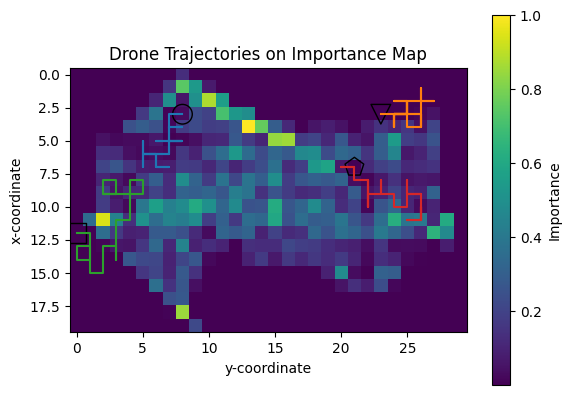

Length of drone state's vector: 4
What is inside: [[0.2, 0.8, 0.7666666666666667, 1.4666666666666668, np.float64(8.285460351648839), np.float64(0.4243933698248973), np.float64(4.902458531373835), np.float64(4.7579894161363026), np.float64(0.08159859943164621), np.float64(1.0), np.float64(0.8560277777777778), np.float64(1.0), np.float64(0.8697204545454545)], [0.4, 2.3000000000000003, 0.7000000000000001, 0.9666666666666667, np.float64(0.03870525437252887), np.float64(2.3264886764553223), np.float64(0.4665808229672401), np.float64(0.8864279813991178), np.float64(0.09462690278803512), np.float64(0.78125), np.float64(0.8767812500000001), np.float64(0.9630489130434782), np.float64(0.6510357142857144)], [1.1, 0.0, 0.46666666666666673, 1.7333333333333334, np.float64(9.999999999999999e-06), np.float64(1.2499999999999999e-06), np.float64(0.0), np.float64(3.084146069454267), np.float64(1e-06), np.float64(1.0), np.float64(0.6316666666666667), 0.0, np.float64(0.9360416666666667)], [0.8, 2.1, 0.5666

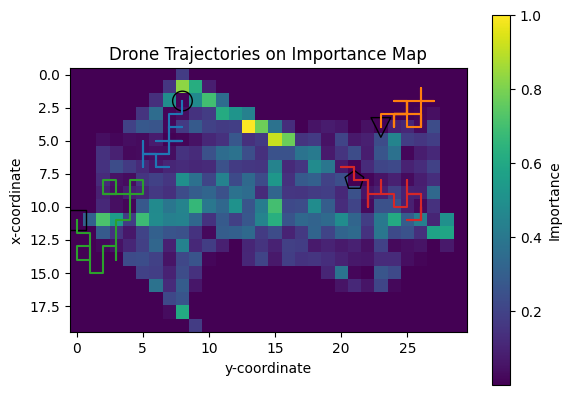

Length of drone state's vector: 4
What is inside: [[0.30000000000000004, 0.8, 0.8333333333333335, 1.4666666666666668, np.float64(0.08096198423272064), np.float64(1.3678593963782864), np.float64(0.07387663861218546), np.float64(1.7327079328376596), np.float64(0.02675301532053251), np.float64(0.7083333333333334), np.float64(0.8953529411764706), np.float64(0.896875), np.float64(0.799971283409091)], [0.5, 2.3000000000000003, 0.7666666666666667, 0.9666666666666667, np.float64(0.10960189795308051), np.float64(2.0040139542304916), np.float64(0.5985176626866678), np.float64(3.948833035619451), np.float64(0.20853690457212937), np.float64(0.655), np.float64(0.8719), np.float64(0.8989701086956522), np.float64(0.8714285714285713)], [1.1, 0.0, 0.5666666666666668, 1.7333333333333334, np.float64(9.999999999999999e-06), np.float64(1.5e-06), np.float64(0.0), np.float64(2.6374073598127463), np.float64(1.0000000000000002e-07), np.float64(1.0), np.float64(0.63), 0.0, np.float64(0.9363750000000001)], [0.9,

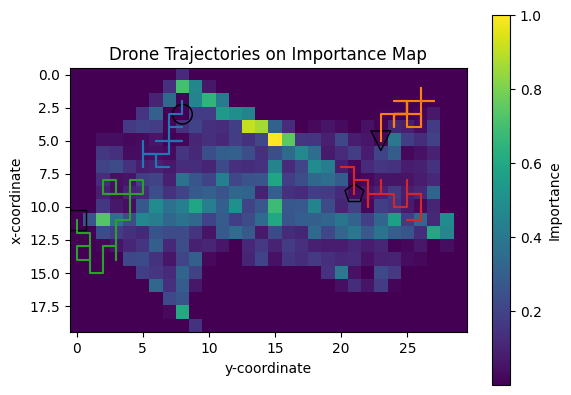

Length of drone state's vector: 4
What is inside: [[0.2, 0.8, 0.8333333333333335, 1.5333333333333334, np.float64(4.779933234003716), np.float64(0.0944454011817765), np.float64(4.697136387351544), np.float64(4.35425213423232), np.float64(0.00548497919098708), np.float64(1.0), np.float64(0.8490833333333333), np.float64(1.0), np.float64(0.8748340909090909)], [0.5, 2.3000000000000003, 0.7333333333333334, 1.0333333333333334, np.float64(0.023399549669996435), np.float64(2.320632285634876), np.float64(0.25981059157831893), np.float64(2.9134295642391512), np.float64(0.014537071007524178), np.float64(0.6649999999999999), np.float64(0.8692333333333333), np.float64(0.9033179347826088), np.float64(0.8585714285714285)], [1.1, 0.1, 0.5333333333333333, 1.7666666666666668, np.float64(9.999999999999999e-06), np.float64(1.1e-06), np.float64(3.5000000000000004e-07), np.float64(4.707681454349523), np.float64(0.07291119403548445), np.float64(1.0), np.float64(0.5555555555555556), np.float64(0.035), np.float

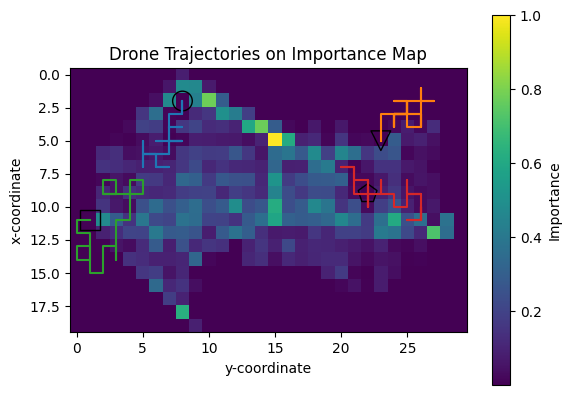

Length of drone state's vector: 4
What is inside: [[0.2, 0.7000000000000001, 0.8333333333333335, 1.5, np.float64(0.5216412053217244), np.float64(0.0040504690775625025), np.float64(0.2929701447137226), np.float64(0.006164551979400273), np.float64(0.42241385727077585), np.float64(1.0), np.float64(0.758357638888889), np.float64(1.0), np.float64(0.8454934782608695)], [0.5, 2.4000000000000004, 0.7333333333333334, 0.9333333333333335, np.float64(4.772500000000002e-06), np.float64(0.11653790838443245), np.float64(0.0013137113182994666), np.float64(0.18410433946362995), np.float64(5.297216378428629e-05), np.float64(0.58551157), np.float64(0.8983333333333334), np.float64(0.8713046875), np.float64(0.85)], [1.1, 0.0, 0.5333333333333333, 1.7333333333333334, np.float64(9.999999999999999e-06), np.float64(1.9999999999999995e-06), np.float64(0.0), np.float64(0.07631125428947902), np.float64(3.5e-08), np.float64(1.0), np.float64(0.6459444444444444), 0.0, np.float64(0.9119916666666668)], [0.9, 2.1, 0.600

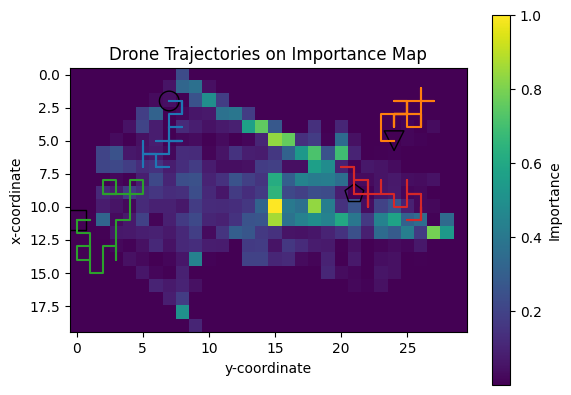

Length of drone state's vector: 4
What is inside: [[0.1, 0.7000000000000001, 0.8666666666666667, 1.5, np.float64(9.999999999999999e-06), np.float64(0.41352665385372134), np.float64(9.999999999999999e-06), np.float64(1.6227250432424216), np.float64(0.01977069451899565), np.float64(1.0), np.float64(0.7316019736842105), np.float64(1.0), np.float64(0.9597826086956524)], [0.6000000000000001, 2.4000000000000004, 0.7000000000000001, 0.9333333333333335, np.float64(1.2499999999999999e-06), np.float64(9.999999999999999e-06), np.float64(9.999999999999999e-06), np.float64(9.999999999999999e-06), np.float64(1e-06), np.float64(0.5212596416666667), np.float64(0.8946428571428572), np.float64(0.9151854166666666), np.float64(0.85)], [1.0, 0.0, 0.5666666666666668, 1.7333333333333334, np.float64(9.999999999999999e-06), np.float64(2.85e-07), np.float64(0.0), np.float64(9.999999999999999e-06), np.float64(1e-06), np.float64(1.0), np.float64(0.60135), 0.0, np.float64(0.8854641666666668)], [1.0, 2.1, 0.5666666

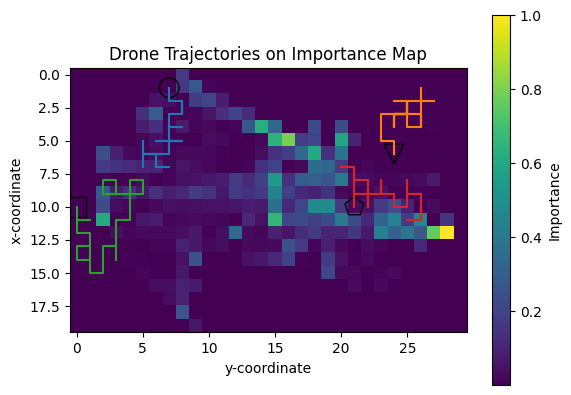

Length of drone state's vector: 4
What is inside: [[0.1, 0.7000000000000001, 0.9, 1.5333333333333334, np.float64(9.999999999999999e-06), np.float64(0.5003638142253166), np.float64(9.999999999999999e-06), np.float64(3.502684623725198), np.float64(0.001306729013817458), np.float64(1.0), np.float64(0.7347598684210527), np.float64(1.0), np.float64(0.9569565217391304)], [0.6000000000000001, 2.5, 0.7333333333333334, 0.9333333333333335, np.float64(9.999999999999999e-06), np.float64(9.999999999999999e-06), np.float64(1.2499999999999999e-06), np.float64(9.999999999999999e-06), np.float64(1e-06), np.float64(0.7232933975), np.float64(0.8894892857142859), np.float64(0.8865780000000001), np.float64(0.82)], [1.1, 0.0, 0.5666666666666668, 1.7666666666666668, np.float64(1.2499999999999999e-06), np.float64(2.4999999999999994e-06), np.float64(0.0), np.float64(0.02282320724407713), np.float64(2.8499999999999997e-08), np.float64(0.9204545454545454), np.float64(0.6625388888888888), 0.0, np.float64(0.918636

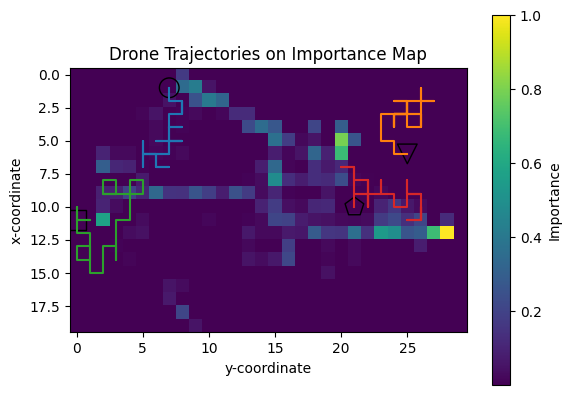

Length of drone state's vector: 4
What is inside: [[0.0, 0.7000000000000001, 0.9, 1.5, np.float64(0.0), np.float64(0.0067004478159860565), np.float64(9.999999999999999e-06), np.float64(0.925883061857508), np.float64(1e-06), 0.0, np.float64(0.7117718749999999), np.float64(1.0), np.float64(0.9608695652173914)], [0.5, 2.5, 0.7333333333333334, 0.9, np.float64(9.250000000000005e-06), np.float64(1.2499999999999999e-06), np.float64(1.75e-06), np.float64(9.999999999999999e-06), np.float64(1e-06), np.float64(0.6829520770000002), np.float64(0.8435233333333334), np.float64(0.8564525000000001), np.float64(0.82)], [1.2000000000000002, 0.0, 0.5, 1.7333333333333334, np.float64(2.7849999999999996e-07), np.float64(4.500000000000001e-06), np.float64(0.0), np.float64(2.1e-06), np.float64(2.4999999999999994e-07), np.float64(0.8481541666666668), np.float64(0.723125), 0.0, np.float64(0.932)], [1.0, 2.0, 0.5666666666666668, 1.0666666666666667, np.float64(9.999999999999999e-06), np.float64(9.999999999999999e-

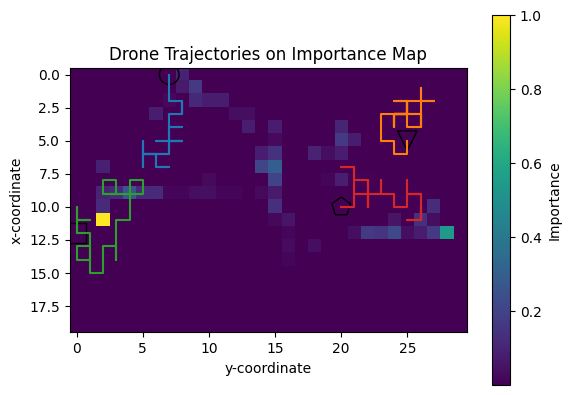

Length of drone state's vector: 4
What is inside: [[0.0, 0.6000000000000001, 0.9, 1.5, np.float64(0.0), np.float64(9.999999999999999e-06), np.float64(9.999999999999999e-06), np.float64(1.2499999999999999e-06), np.float64(1e-06), 0.0, np.float64(0.9065004999999999), np.float64(1.0), np.float64(0.9260416666666668)], [0.6000000000000001, 2.5, 0.7000000000000001, 0.8666666666666667, np.float64(1.2499999999999999e-06), np.float64(9.999999999999999e-06), np.float64(1.75e-06), np.float64(9.999999999999999e-06), np.float64(1.25e-07), np.float64(0.6024600641666668), np.float64(0.8939535714285716), np.float64(0.8945780000000001), np.float64(0.8025)], [1.1, 0.0, 0.5333333333333333, 1.7000000000000002, np.float64(1.75e-06), np.float64(5e-07), np.float64(0.0), np.float64(2.2499999999999996e-06), np.float64(2.785e-08), np.float64(0.925), np.float64(0.6514205555555557), 0.0, np.float64(0.9253011666666667)], [1.0, 2.0, 0.5666666666666668, 1.0333333333333334, np.float64(9.999999999999999e-06), np.float

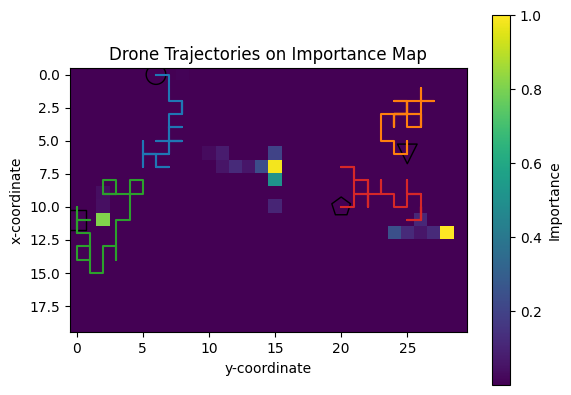

Length of drone state's vector: 4
What is inside: [[0.0, 0.7000000000000001, 0.9, 1.4333333333333336, np.float64(0.0), np.float64(8.500000000000001e-07), np.float64(1.2499999999999999e-06), np.float64(9.999999999999999e-06), np.float64(1.25e-07), 0.0, np.float64(0.724896875), np.float64(0.875), np.float64(0.9570652173913043)], [0.6000000000000001, 2.4000000000000004, 0.7000000000000001, 0.8666666666666667, np.float64(2.2499999999999996e-06), np.float64(9.999999999999999e-06), np.float64(9.999999999999999e-06), np.float64(3.7500000000000006e-07), np.float64(1.7499999999999997e-07), np.float64(0.5879263083333334), np.float64(0.9030357142857144), np.float64(0.9276854166666667), np.float64(0.6758333333333333)], [1.1, 0.0, 0.5333333333333333, 1.666666666666667, np.float64(1.9999999999999995e-06), np.float64(7.500000000000001e-07), np.float64(0.0), np.float64(2.4999999999999994e-06), np.float64(2.785e-09), np.float64(0.9272727272727272), np.float64(0.659475388888889), 0.0, np.float64(0.92855

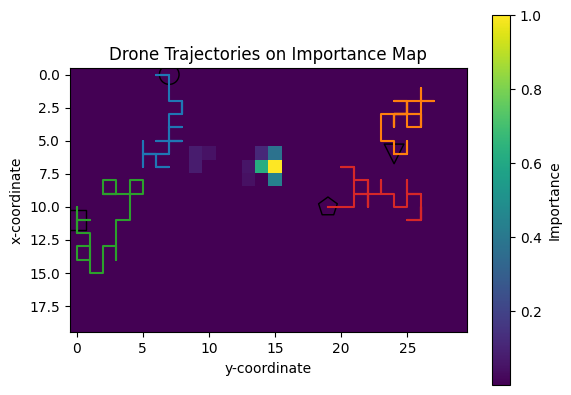

Length of drone state's vector: 4
What is inside: [[0.0, 0.8, 0.9, 1.4666666666666668, np.float64(0.0), np.float64(9.999999999999999e-06), np.float64(3.7500000000000006e-07), np.float64(9.999999999999999e-06), np.float64(1e-06), 0.0, np.float64(0.845425), np.float64(0.7734375), np.float64(0.9590909090909091)], [0.6000000000000001, 2.4000000000000004, 0.7000000000000001, 0.9333333333333335, np.float64(2.4999999999999994e-06), np.float64(9.999999999999999e-06), np.float64(9.999999999999999e-06), np.float64(6.249999999999999e-07), np.float64(1.7499999999999998e-08), np.float64(0.6045929750000001), np.float64(0.905482142857143), np.float64(0.9308104166666666), np.float64(0.677375)], [1.1, 0.1, 0.5333333333333333, 1.7000000000000002, np.float64(9.999999999999999e-06), np.float64(2.8500000000000002e-06), np.float64(2.52785e-07), np.float64(9.999999999999999e-06), np.float64(2.4999999999999994e-07), np.float64(1.0), np.float64(0.625), np.float64(0.025278500000000002), np.float64(0.95517241379

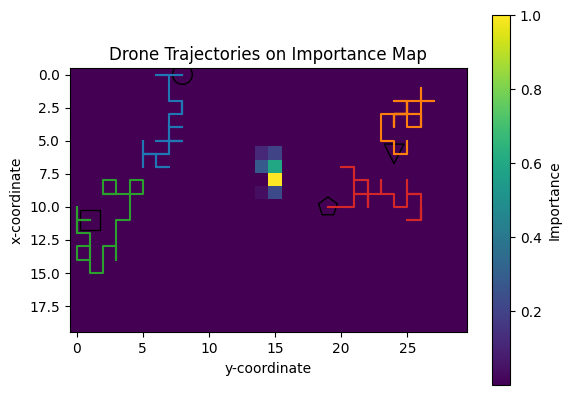

Length of drone state's vector: 4
What is inside: [[0.0, 0.8, 0.8666666666666667, 1.4666666666666668, np.float64(0.0), np.float64(9.999999999999999e-06), np.float64(6.249999999999999e-07), np.float64(9.999999999999999e-06), np.float64(1.0000000000000002e-07), 0.0, np.float64(0.844675), np.float64(0.7796875), np.float64(0.955)], [0.5, 2.4000000000000004, 0.7000000000000001, 0.9333333333333335, np.float64(6.522500000000003e-06), np.float64(2.6750000000000003e-07), np.float64(2.1e-06), np.float64(1.9999999999999995e-06), np.float64(2.4999999999999994e-07), np.float64(0.6905115700000002), np.float64(0.8517833333333334), np.float64(0.9015130208333334), np.float64(0.7041666666666666)], [1.0, 0.1, 0.5333333333333333, 1.7000000000000002, np.float64(9.999999999999999e-06), np.float64(5e-07), np.float64(2.4999999999999994e-06), np.float64(9.999999999999999e-06), np.float64(1e-06), np.float64(1.0), np.float64(0.5850000000000001), np.float64(0.24999999999999997), np.float64(0.8436637931034485)], [

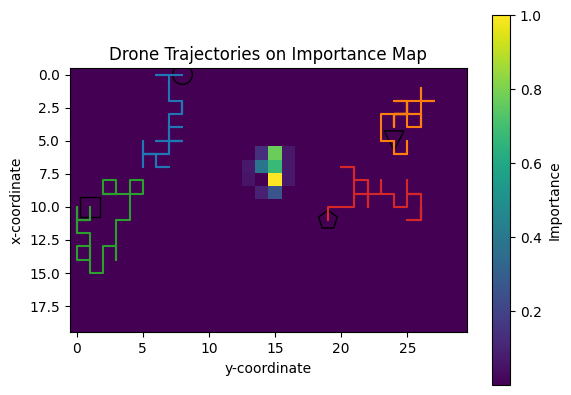

Length of drone state's vector: 4
What is inside: [[0.0, 0.7000000000000001, 0.9333333333333335, 1.5, np.float64(0.0), np.float64(1.6e-06), np.float64(1.9999999999999995e-06), np.float64(3.5000000000000004e-07), np.float64(6.25e-08), 0.0, np.float64(0.750834375), np.float64(0.8857142857142858), np.float64(0.914836956521739)], [0.5, 2.5, 0.7666666666666667, 0.9, np.float64(9.999999999999999e-06), np.float64(1.1249999999999998e-06), np.float64(5e-07), np.float64(9.999999999999999e-06), np.float64(2e-07), np.float64(0.7479520770000001), np.float64(0.8606900000000001), np.float64(0.8714525000000001), np.float64(0.8039999999999999)], [1.1, 0.1, 0.5666666666666668, 1.7000000000000002, np.float64(1.2499999999999999e-06), np.float64(3.350000000000001e-06), np.float64(7.527849999999999e-07), np.float64(9.999999999999999e-06), np.float64(5.000000000000001e-08), np.float64(0.9204545454545454), np.float64(0.645), np.float64(0.0752785), np.float64(0.9277586206896552)], [1.2000000000000002, 1.900000

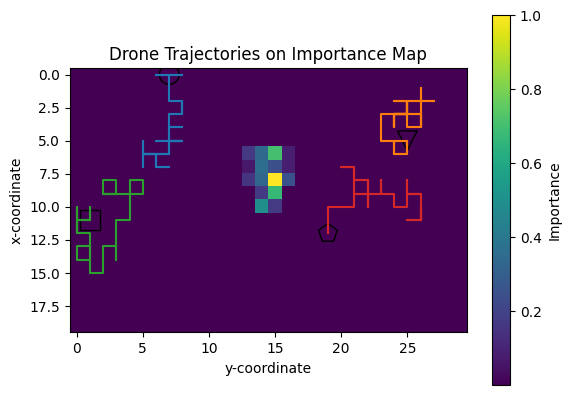

Length of drone state's vector: 4
What is inside: [[0.0, 0.8, 0.9, 1.4333333333333336, np.float64(0.0), np.float64(9.999999999999999e-06), np.float64(3.1249999999999997e-07), np.float64(9.999999999999999e-06), np.float64(3.5e-08), 0.0, np.float64(0.85185), np.float64(0.78203125), np.float64(0.9547045454545454)], [0.4, 2.5, 0.7666666666666667, 0.8666666666666667, np.float64(3.835353850000001e-06), np.float64(4.5e-07), np.float64(7.0225000000000035e-06), np.float64(5.800000000000003e-06), np.float64(1e-06), np.float64(0.69744009625), np.float64(0.819396875), np.float64(0.9420949999999999), np.float64(0.736)], [1.1, 0.0, 0.5333333333333333, 1.7000000000000002, np.float64(3e-06), np.float64(1.75e-06), np.float64(0.0), np.float64(3.0000000000000004e-07), np.float64(7.52785e-08), np.float64(0.9363636363636364), np.float64(0.6936142055555555), 0.0, np.float64(0.900417595)], [1.2000000000000002, 1.8, 0.5, 1.1, np.float64(9.999999999999999e-06), np.float64(9.999999999999999e-06), np.float64(9.9

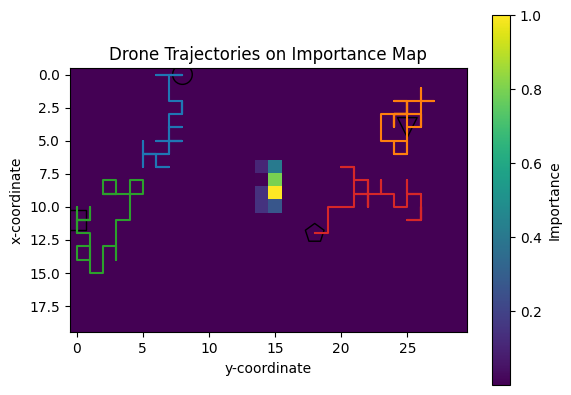

Length of drone state's vector: 4
What is inside: [[0.0, 0.7000000000000001, 0.9, 1.5, np.float64(0.0), np.float64(2.1e-06), np.float64(2.4999999999999994e-06), np.float64(2.85e-07), np.float64(3.125e-08), 0.0, np.float64(0.768178125), np.float64(0.8928571428571429), np.float64(0.9144184782608695)], [0.4, 2.5, 0.7666666666666667, 0.9, np.float64(4.085353850000002e-06), np.float64(7.000000000000001e-07), np.float64(7.272500000000004e-06), np.float64(6.050000000000002e-06), np.float64(1.0000000000000002e-07), np.float64(0.70994009625), np.float64(0.820021875), np.float64(0.945095), np.float64(0.7230000000000001)], [1.1, 0.1, 0.5333333333333333, 1.7000000000000002, np.float64(1.75e-06), np.float64(3.850000000000001e-06), np.float64(3.252785e-07), np.float64(9.999999999999999e-06), np.float64(3.0000000000000004e-08), np.float64(0.925), np.float64(0.667), np.float64(0.032527850000000004), np.float64(0.9328620689655173)], [1.2000000000000002, 1.9000000000000001, 0.5, 1.1, np.float64(1.75e-06

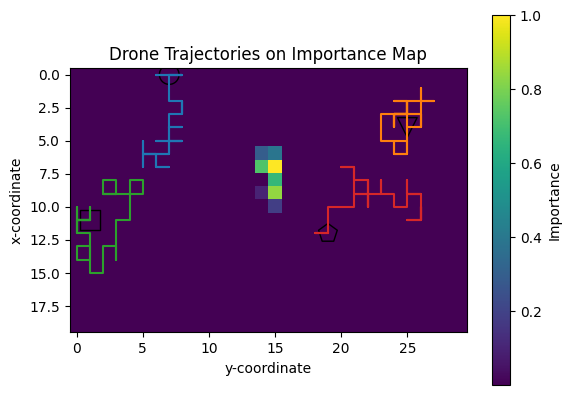

Length of drone state's vector: 4
What is inside: [[0.0, 0.7000000000000001, 0.9, 1.4333333333333336, np.float64(0.0), np.float64(2.3499999999999995e-06), np.float64(2.7499999999999995e-06), np.float64(5.350000000000001e-07), np.float64(3.1250000000000007e-09), 0.0, np.float64(0.7767875), np.float64(0.8964285714285715), np.float64(0.915383152173913)], [0.4, 2.4000000000000004, 0.7666666666666667, 0.8666666666666667, np.float64(4.253078500000001e-06), np.float64(1.2499999999999999e-06), np.float64(4.500000000000001e-06), np.float64(3.5000000000000004e-07), np.float64(7.272500000000003e-07), np.float64(0.7500769625000001), np.float64(0.8280921875), np.float64(0.9562552083333333), np.float64(0.6229541666666667)], [1.1, 0.1, 0.5333333333333333, 1.6333333333333333, np.float64(1.9999999999999995e-06), np.float64(4.100000000000001e-06), np.float64(5.752785000000001e-07), np.float64(9.999999999999999e-06), np.float64(3.0000000000000004e-09), np.float64(0.9272727272727272), np.float64(0.6778111

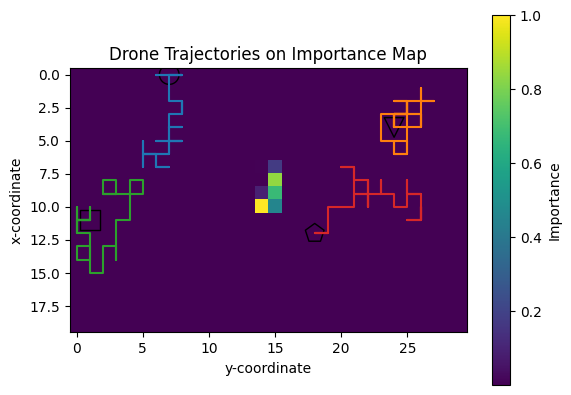

Length of drone state's vector: 4
What is inside: [[0.0, 0.8, 0.9, 1.4333333333333336, np.float64(0.0), np.float64(9.999999999999999e-06), np.float64(2.53125e-07), np.float64(9.999999999999999e-06), np.float64(5.350000000000001e-08), 0.0, np.float64(0.8631925), np.float64(0.7906640625), np.float64(0.9547886363636363)], [0.4, 2.4000000000000004, 0.7666666666666667, 0.9, np.float64(4.503078500000001e-06), np.float64(1.5e-06), np.float64(4.750000000000001e-06), np.float64(6.000000000000001e-07), np.float64(7.272500000000004e-08), np.float64(0.7625769625000001), np.float64(0.83025140625), np.float64(0.9583385416666667), np.float64(0.6203787500000001)], [1.1, 0.2, 0.5333333333333333, 1.6333333333333333, np.float64(9.999999999999999e-06), np.float64(9.999999999999999e-06), np.float64(2.53e-07), np.float64(9.750000000000003e-06), np.float64(1e-06), np.float64(1.0), np.float64(0.8233333333333335), np.float64(0.05391392500000001), np.float64(0.9392857142857144)], [1.2000000000000002, 1.70000000

In [5]:
# Set mode: random, greedy, lstm, nn
mode = 'greedy'
run(link, df_link, ['000'], id = 'pred_vdist', mode = 'random', load = False)